# CA Healthcare Burden Analysis
**Data year: 2024 (chargemaster + mortality) | Census:  2024 **

## Notebook structure
| Block | Goal |
|---|---|
| 0 | Configuration & imports |
| 1 | Census API pull — socioeconomic variables for all CA ZIPs |
| 2 | Load & clean chargemaster data (matched_rows_with_zip.csv) |
| 3 | Load & clean mortality data |
| 4 | Build ZIP × CPT master dataset |
| 5 | Build ZIP-level aggregate dataset |
| 6 | Compute all five indexes + HVI |
| 7 | Regression analysis (OLS, fixed effects, mortality model) |
| 8 | Summary outputs & export |

> **Re-run safety**: Each block checks for a cached CSV before pulling/computing. Delete the cache file to force a fresh run.

---
## Block 0 — Configuration & imports
**Goal**: Set all file paths, API keys, and year constants in one place. Edit only this block when paths change.

In [4]:
import os
import requests
import numpy as np
import pandas as pd
import warnings
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:/Users/Parvati/Downloads")

# Inputs
CHARGEMASTER_FILE = BASE_DIR / "matched_rows_with_zip.csv"   # output of your merge script
MORTALITY_FILE    = BASE_DIR / "charge_master_ca_deathcounts.csv"

# Cache / intermediate outputs (re-run safe)
CENSUS_CACHE      = BASE_DIR / "cache_census_zip.csv"
CHARGE_CLEAN      = BASE_DIR / "cache_chargemaster_clean.csv"
MORTALITY_CLEAN   = BASE_DIR / "cache_mortality_clean.csv"
MASTER_CPT        = BASE_DIR / "cache_master_zip_cpt.csv"    # ZIP × CPT level
MASTER_ZIP        = BASE_DIR / "cache_master_zip.csv"        # ZIP level aggregate
INDEXES_ZIP       = BASE_DIR / "cache_indexes_zip.csv"       # all indexes

# Final outputs
OUT_REGRESSION    = BASE_DIR / "output_regression_results.csv"
OUT_TOP_BURDEN    = BASE_DIR / "output_top_burden_zips.csv"
OUT_FULL          = BASE_DIR / "output_full_analysis_dataset.csv"

# ── Constants ────────────────────────────────────────────────────────────────
CENSUS_API_KEY    = "xxx"   # <── paste your key
CENSUS_YEAR       = 2024          # Most recent ACS 5-yr with ZIP coverage
CHARGEMASTER_YEAR = "2024"        # Filter chargemaster to this year
MORTALITY_YEAR    = "2024"        # Filter mortality to this year
CA_STATE_FIPS     = "06"          # California

# CPT code groups — edit to add/remove codes
EMERGENCY_CPTS = [
    "99281","99282","99283","99284","99285",  # ED E&M levels
    "99291","99292",                            # Critical care
    "99281-99285",                              # Range notation some hospitals use
]
DELIVERY_CPTS  = [
    "59400","59410","59409",                    # Vaginal delivery
    "59510","59514","59515",                    # C-section
    "59610","59618","59620","59622",            # VBAC
    "59430",                                    # Postpartum care
]
ALL_TARGET_CPTS = EMERGENCY_CPTS + DELIVERY_CPTS

print("✓ Config loaded")
print(f"  Chargemaster : {CHARGEMASTER_FILE}")
print(f"  Mortality    : {MORTALITY_FILE}")
print(f"  Census year  : {CENSUS_YEAR} ACS 5-year")
print(f"  CA FIPS      : {CA_STATE_FIPS}")

✓ Config loaded
  Chargemaster : C:\Users\Parvati\Downloads\matched_rows_with_zip.csv
  Mortality    : C:\Users\Parvati\Downloads\charge_master_ca_deathcounts.csv
  Census year  : 2024 ACS 5-year
  CA FIPS      : 06


In [6]:
# ── Reload all cached dataframes + clear index cache for recompute ────────────
import os
import pandas as pd
import numpy as np

# ── Clear index cache only (HVI updated — price removed) ─────────────────────
if INDEXES_ZIP.exists():
    os.remove(INDEXES_ZIP)
    print(f"✓ Deleted index cache: {INDEXES_ZIP}")

# ── Reload all other caches into memory ───────────────────────────────────────
df_census = pd.read_csv(CENSUS_CACHE, dtype={"zip": str})
print(f"✓ Census loaded: {len(df_census):,} ZIPs")

df_charge = pd.read_csv(CHARGE_CLEAN, dtype={"zip": str, "procedure_code": str})
print(f"✓ Chargemaster loaded: {len(df_charge):,} rows")

df_mort = pd.read_csv(MORTALITY_CLEAN, dtype={"zip": str})
print(f"✓ Mortality loaded: {len(df_mort):,} ZIPs")

df_cpt = pd.read_csv(MASTER_CPT, dtype={"zip": str, "procedure_code": str})
print(f"✓ ZIP × CPT loaded: {len(df_cpt):,} rows")

df_zip = pd.read_csv(MASTER_ZIP, dtype={"zip": str})
print(f"✓ ZIP aggregate loaded: {len(df_zip):,} ZIPs")

✓ Census loaded: 1,762 ZIPs
✓ Chargemaster loaded: 3,005 rows
✓ Mortality loaded: 1,425 ZIPs
✓ ZIP × CPT loaded: 1,650 rows
✓ ZIP aggregate loaded: 308 ZIPs


---
## Block 1 — Census API pull
**Goal**: Pull socioeconomic variables for all California ZIPs from ACS 5-year 2024.
Variables pulled:
- `B19013_001E` → Median household income
- `B01003_001E` → Total population  
- `B17001_002E` → Count below poverty line
- `B17001_001E` → Poverty universe total (denominator)
- `S2701_C05_001E` → % uninsured (Subject Table)
- `S1810_C03_001E` → % with disability (Subject Table)
- `S0101_C02_030E` → % age 65+ (Subject Table)

Saves to `cache_census_zip.csv` — skips pull if file exists.

In [6]:
# ── Re-run guard ─────────────────────────────────────────────────────────────
if CENSUS_CACHE.exists():
    df_census = pd.read_csv(CENSUS_CACHE, dtype={"zip": str})
    print(f"✓ Loaded from cache: {CENSUS_CACHE} ({len(df_census):,} ZIPs)")
else:
    print("Pulling Census API...")

    BASE_URL = f"https://api.census.gov/data/{CENSUS_YEAR}/acs"

    # ── Helper ───────────────────────────────────────────────────────────────
    def census_get(endpoint, variables, key):
        """Pull variables from a Census ACS endpoint for all CA ZCTAs."""
        var_str = ",".join(["NAME"] + variables)
        url = (
            f"{BASE_URL}/{endpoint}"
            f"?get={var_str}"
            f"&for=zip%20code%20tabulation%20area:*"
            f"&in=state:{CA_STATE_FIPS}"
            f"&key={key}"
        )
        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            # ZCTAs don't support state filter on all endpoints — retry without
            url2 = (
                f"{BASE_URL}/{endpoint}"
                f"?get={var_str}"
                f"&for=zip%20code%20tabulation%20area:*"
                f"&key={key}"
            )
            r = requests.get(url2, timeout=60)
        r.raise_for_status()
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])
        df = df.rename(columns={"zip code tabulation area": "zip"})
        return df

    # ── Pull 1: Detailed tables (B-series) ───────────────────────────────────
    detail_vars = [
        "B19013_001E",   # median household income
        "B01003_001E",   # total population
        "B17001_002E",   # count below poverty
        "B17001_001E",   # poverty universe total
    ]
    df_detail = census_get("acs5", detail_vars, CENSUS_API_KEY)
    print(f"  Detail tables: {len(df_detail):,} ZCTAs")

    # ── Pull 2: Subject tables (S-series) ────────────────────────────────────
    subject_vars = [
        "S2701_C05_001E",  # % uninsured
        "S1810_C03_001E",  # % with disability
        "S0101_C02_030E",  # % age 65+
    ]
    df_subject = census_get("acs5/subject", subject_vars, CENSUS_API_KEY)
    print(f"  Subject tables: {len(df_subject):,} ZCTAs")

    # ── Merge pulls ──────────────────────────────────────────────────────────
    df_census = df_detail.merge(df_subject[["zip"] + subject_vars], on="zip", how="left")

    # ── Convert to numeric ───────────────────────────────────────────────────
    num_cols = detail_vars + subject_vars
    for col in num_cols:
        df_census[col] = pd.to_numeric(df_census[col], errors="coerce")
        df_census[col] = df_census[col].replace(-666666666, np.nan)  # Census null sentinel

    # ── Derived columns ──────────────────────────────────────────────────────
    df_census["median_income"]   = df_census["B19013_001E"]
    df_census["total_pop"]       = df_census["B01003_001E"]
    df_census["poverty_rate"]    = (
        df_census["B17001_002E"] / df_census["B17001_001E"]
    ).clip(0, 1)
    df_census["pct_uninsured"]   = df_census["S2701_C05_001E"] / 100
    df_census["pct_disability"]  = df_census["S1810_C03_001E"] / 100
    df_census["pct_elderly"]     = df_census["S0101_C02_030E"] / 100

    # ── Filter to CA ZIPs only (if national pull was needed) ─────────────────
    # CA ZCTAs are roughly 90001–96162; keep only those
    df_census["zip"] = df_census["zip"].astype(str).str.zfill(5)
    ca_mask = df_census["zip"].between("90001", "96162")
    df_census = df_census[ca_mask].copy()

    # ── Keep clean columns only ──────────────────────────────────────────────
    keep = ["zip", "median_income", "total_pop", "poverty_rate",
            "pct_uninsured", "pct_disability", "pct_elderly"]
    df_census = df_census[keep]

    df_census.to_csv(CENSUS_CACHE, index=False)
    print(f"✓ Saved: {CENSUS_CACHE} ({len(df_census):,} CA ZIPs)")

# ── Quick QC ─────────────────────────────────────────────────────────────────
print("\nCensus data summary:")
display(df_census.describe().round(2))
print(f"Missing income: {df_census['median_income'].isna().sum()}")
print(f"Missing poverty: {df_census['poverty_rate'].isna().sum()}")

Pulling Census API...
  Detail tables: 33,772 ZCTAs
  Subject tables: 33,772 ZCTAs
✓ Saved: C:\Users\Parvati\Downloads\cache_census_zip.csv (1,802 CA ZIPs)

Census data summary:


,median_income,total_pop,poverty_rate,pct_uninsured,pct_disability,pct_elderly
count,1590.00,1802.00,1734.00,1744.00,1744.00,1762.00
mean,101861.75,21801.47,0.14,0.06,0.14,0.20
std,44171.10,22368.31,0.12,0.06,0.09,0.14
min,2499.00,0.00,0.00,0.00,0.00,0.00
25%,70576.50,1366.00,0.07,0.03,0.09,0.12
50%,93711.50,15058.50,0.11,0.05,0.12,0.17
75%,122803.25,36810.50,0.17,0.08,0.15,0.24
max,250001.00,105517.00,1.00,0.93,1.00,1.00


Missing income: 212
Missing poverty: 68


In [7]:
# Drop zero-population ZIPs — can't compute per-capita anything
df_census = df_census[df_census['total_pop'] > 0].copy()
df_census.to_csv(CENSUS_CACHE, index=False)
print(f"After dropping zero-pop ZIPs: {len(df_census):,}")

After dropping zero-pop ZIPs: 1,762


---
## Block 2 — Load & clean chargemaster data
**Goal**: Load matched_rows_with_zip.csv, filter to 2024 and target CPT codes,
standardize procedure codes, and compute numeric charges.
Saves to `cache_chargemaster_clean.csv`.

In [8]:
# ── Re-run guard ─────────────────────────────────────────────────────────────
if CHARGE_CLEAN.exists():
    df_charge = pd.read_csv(CHARGE_CLEAN, dtype={"zip": str, "procedure_code": str})
    print(f"✓ Loaded from cache: {CHARGE_CLEAN} ({len(df_charge):,} rows)")
else:
    print("Loading chargemaster...")
    df_raw = pd.read_csv(CHARGEMASTER_FILE, dtype=str)
    print(f"  Raw rows: {len(df_raw):,} | Columns: {df_raw.columns.tolist()}")

    # ── Standardize column names ──────────────────────────────────────────────
    df_raw.columns = df_raw.columns.str.strip().str.lower()

    # ── Filter to 2024 ────────────────────────────────────────────────────────
    df_raw["year"] = df_raw["year"].astype(str).str.strip()
    df_charge = df_raw[df_raw["year"] == CHARGEMASTER_YEAR].copy()
    print(f"  After year filter ({CHARGEMASTER_YEAR}): {len(df_charge):,} rows")

    # ── Clean procedure codes ─────────────────────────────────────────────────
    # Strip whitespace, leading zeros inconsistencies, dashes
    df_charge["procedure_code"] = (
        df_charge["procedure_code"]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"[^A-Z0-9]", "", regex=True)  # remove dashes, spaces
    )

    # ── Classify CPT codes ────────────────────────────────────────────────────
    emergency_set = {c.replace("-", "").upper() for c in EMERGENCY_CPTS}
    delivery_set  = {c.replace("-", "").upper() for c in DELIVERY_CPTS}

    def classify_cpt(code):
        if code in emergency_set:
            return "emergency"
        elif code in delivery_set:
            return "delivery"
        return None

    df_charge["cpt_group"] = df_charge["procedure_code"].map(classify_cpt)
    df_charge = df_charge[df_charge["cpt_group"].notna()].copy()
    print(f"  After CPT filter: {len(df_charge):,} rows")
    print(f"  Emergency rows: {(df_charge['cpt_group']=='emergency').sum():,}")
    print(f"  Delivery rows:  {(df_charge['cpt_group']=='delivery').sum():,}")

    # ── Numeric charge ────────────────────────────────────────────────────────
    # Use charge_numeric if available, else parse charge column
    if "charge_numeric" in df_charge.columns:
        df_charge["price"] = pd.to_numeric(df_charge["charge_numeric"], errors="coerce")
    else:
        df_charge["price"] = (
            df_charge["charge"]
            .astype(str)
            .str.replace(r"[\$,]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )

    # Drop zero/negative/extreme prices
    df_charge = df_charge[df_charge["price"] > 0].copy()
    p99 = df_charge["price"].quantile(0.99)
    df_charge = df_charge[df_charge["price"] <= p99].copy()  # cap extreme outliers
    print(f"  After price cleaning (p99 cap = ${p99:,.0f}): {len(df_charge):,} rows")

    # ── Clean ZIP ─────────────────────────────────────────────────────────────
    df_charge["zip"] = (
        df_charge["zip"]
        .astype(str)
        .str.extract(r"(\d{5})", expand=False)
    )
    df_charge = df_charge.dropna(subset=["zip", "price"]).copy()

    # ── Keep clean columns ────────────────────────────────────────────────────
    keep = ["year", "hospital", "zip", "procedure_code", "cpt_group",
            "description", "price"]
    keep = [c for c in keep if c in df_charge.columns]
    df_charge = df_charge[keep]

    df_charge.to_csv(CHARGE_CLEAN, index=False)
    print(f"✓ Saved: {CHARGE_CLEAN}")

# ── Quick QC ─────────────────────────────────────────────────────────────────
print(f"\nUnique hospitals: {df_charge['hospital'].nunique()}")
print(f"Unique ZIPs:      {df_charge['zip'].nunique()}")
print(f"Unique CPT codes: {df_charge['procedure_code'].nunique()}")
display(df_charge.groupby("cpt_group")["price"].describe().round(2))

Loading chargemaster...
  Raw rows: 3,036 | Columns: ['year', 'hospital', 'file_name', 'sheet_name', 'source_column', 'procedure_code', 'code_type', 'description', 'charge', 'charge_column', 'charge_numeric', 'zip']
  After year filter (2024): 3,036 rows
  After CPT filter: 3,036 rows
  Emergency rows: 2,753
  Delivery rows:  283
  After price cleaning (p99 cap = $12,139): 3,005 rows
✓ Saved: C:\Users\Parvati\Downloads\cache_chargemaster_clean.csv

Unique hospitals: 348
Unique ZIPs:      318
Unique CPT codes: 13


,count,mean,std,min,25%,50%,75%,max
cpt_group,,,,,,,,
delivery,282.0,3735.37,1962.79,186.23,1956.52,3596.29,5034.0,9804.0
emergency,2723.0,2913.60,2400.61,10.34,1129.26,2411.00,3965.0,12065.0


In [11]:
df_charge.groupby(['procedure_code', 'cpt_group'])['price'].agg(['mean','count']).round(2)

,,mean,count
procedure_code,cpt_group,,
59400,delivery,5051.45,62
59409,delivery,2903.40,96
59410,delivery,4915.00,2
59510,delivery,5583.13,56
59514,delivery,2069.56,65
59515,delivery,4450.72,1
99281,emergency,555.82,174
99282,emergency,1250.73,557
99283,emergency,2042.37,609


---
## Block 3 — Load & clean mortality data
**Goal**: Filter CA death counts to 2024, all-cause, total population.
Compute deaths_per_100k using Census population. Saves to `cache_mortality_clean.csv`.

In [18]:
import os
if MORTALITY_CLEAN.exists():
    os.remove(MORTALITY_CLEAN)
    print("Mortality cache cleared")

# ── Re-run guard ─────────────────────────────────────────────────────────────
if MORTALITY_CLEAN.exists():
    df_mort = pd.read_csv(MORTALITY_CLEAN, dtype={"zip": str})
    print(f"✓ Loaded from cache: {MORTALITY_CLEAN} ({len(df_mort):,} ZIPs)")
else:
    print("Loading mortality data...")
    df_raw = pd.read_csv(MORTALITY_FILE, dtype=str)
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    print(f"  Columns: {df_raw.columns.tolist()}")

    # ── Filter ────────────────────────────────────────────────────────────────
    df_raw["year"] = df_raw["year"].astype(str).str.strip()
    df_filt = df_raw[
        (df_raw["strata"] == "Total Population") &
        (df_raw["cause"] == "ALL") &
        (df_raw["year"] == MORTALITY_YEAR)
    ].copy()
    print(f"  After filtering to {MORTALITY_YEAR} / ALL / Total Population: {len(df_filt):,} rows")
    
    # Deduplicate ignoring the _id column (which differs but is meaningless)
    df_filt = df_filt.drop(columns=['_id']).drop_duplicates().copy()
    print(f"After deduplication: {df_filt.shape}")


    # ── Clean ZIP and count ───────────────────────────────────────────────────
    df_filt["zip"] = (
        df_filt["zip_code"]
        .astype(str)
        .str.extract(r"(\d{5})", expand=False)
    )
    df_filt["count"] = pd.to_numeric(df_filt["count"], errors="coerce")
    df_filt = df_filt.dropna(subset=["zip", "count"]).copy()

    # ── Aggregate to ZIP (sum all rows per ZIP) ───────────────────────────────
    df_mort_raw = (
        df_filt.groupby("zip", as_index=False)["count"]
        .sum()
        .rename(columns={"count": "deaths"})
    )

    # ── Join Census population to compute rate ────────────────────────────────
    df_mort = df_mort_raw.merge(
        df_census[["zip", "total_pop"]], on="zip", how="left"
    )
    df_mort["deaths_per_100k"] = (
        df_mort["deaths"] / df_mort["total_pop"] * 100_000
    ).replace([np.inf, -np.inf], np.nan)

    # Drop ZIPs with implausible rates (>5000/100k is data error)
    df_mort = df_mort[df_mort["deaths_per_100k"].between(0, 5000)].copy()

    df_mort.to_csv(MORTALITY_CLEAN, index=False)
    print(f"✓ Saved: {MORTALITY_CLEAN} ({len(df_mort):,} ZIPs)")

# ── Quick QC ─────────────────────────────────────────────────────────────────
print(f"\nMortality summary:")
display(df_mort[["deaths", "deaths_per_100k"]].describe().round(2))

Loading mortality data...
  Columns: ['_id', 'year', 'zip_code', 'geography_type', 'strata', 'strata_name', 'cause', 'cause_desc', 'icd_revision', 'count', 'annotation_code', 'annotation_desc', 'data_revision_date']
  After filtering to 2024 / ALL / Total Population: 5,328 rows
After deduplication: (2664, 12)
✓ Saved: C:\Users\Parvati\Downloads\cache_mortality_clean.csv (1,425 ZIPs)

Mortality summary:


,deaths,deaths_per_100k
count,1425.00,1425.00
mean,199.77,836.10
std,158.72,440.59
min,0.00,0.00
25%,57.00,602.00
50%,173.00,749.18
75%,303.00,961.73
max,834.00,4603.17


---
## Block 4 — Build ZIP × CPT master dataset
**Goal**: Aggregate chargemaster to ZIP × CPT level (avg, median, std, count of price observations).
Join Census and mortality. This is the atomic unit for CPT-level regression.
Saves to `cache_master_zip_cpt.csv`.

In [19]:
# ── Re-run guard ─────────────────────────────────────────────────────────────
if MASTER_CPT.exists():
    df_cpt = pd.read_csv(MASTER_CPT, dtype={"zip": str, "procedure_code": str})
    print(f"✓ Loaded from cache: {MASTER_CPT} ({len(df_cpt):,} rows)")
else:
    print("Building ZIP × CPT master dataset...")

    # ── Aggregate chargemaster prices to ZIP × CPT ────────────────────────────
    df_agg = (
        df_charge.groupby(["zip", "procedure_code", "cpt_group"], as_index=False)
        .agg(
            avg_price   = ("price", "mean"),
            median_price= ("price", "median"),
            std_price   = ("price", "std"),
            min_price   = ("price", "min"),
            max_price   = ("price", "max"),
            n_hospitals = ("hospital", "nunique"),   # how many hospitals report this CPT in this ZIP
        )
    )
    df_agg["price_cv"] = (df_agg["std_price"] / df_agg["avg_price"]).fillna(0)  # coefficient of variation
    print(f"  ZIP × CPT rows: {len(df_agg):,}")

    # ── Join Census ───────────────────────────────────────────────────────────
    df_cpt = df_agg.merge(df_census, on="zip", how="left")

    # ── Join mortality ────────────────────────────────────────────────────────
    df_cpt = df_cpt.merge(
        df_mort[["zip", "deaths", "deaths_per_100k"]], on="zip", how="left"
    )

    # ── Derived columns ───────────────────────────────────────────────────────
    # Log price (for regression — price is right-skewed)
    df_cpt["log_avg_price"] = np.log1p(df_cpt["avg_price"])

    # Raw burden: price as fraction of annual income
    df_cpt["price_income_ratio"] = df_cpt["avg_price"] / df_cpt["median_income"]

    df_cpt.to_csv(MASTER_CPT, index=False)
    print(f"✓ Saved: {MASTER_CPT}")

# ── Quick QC ─────────────────────────────────────────────────────────────────
print(f"\nUnique ZIPs in master: {df_cpt['zip'].nunique()}")
print(f"Unique CPT codes:      {df_cpt['procedure_code'].nunique()}")
print(f"Census join rate:      {df_cpt['median_income'].notna().mean():.1%}")
print(f"Mortality join rate:   {df_cpt['deaths_per_100k'].notna().mean():.1%}")
display(df_cpt[["avg_price", "median_price", "price_cv", "n_hospitals"]].describe().round(2))

Building ZIP × CPT master dataset...
  ZIP × CPT rows: 1,679
✓ Saved: C:\Users\Parvati\Downloads\cache_master_zip_cpt.csv

Unique ZIPs in master: 318
Unique CPT codes:      13
Census join rate:      99.2%
Mortality join rate:   99.2%


,avg_price,median_price,price_cv,n_hospitals
count,1679.00,1679.00,1679.00,1679.00
mean,3115.77,3138.00,0.10,1.16
std,2309.05,2305.57,0.25,0.45
min,13.39,13.39,0.00,1.00
25%,1360.00,1360.00,0.00,1.00
50%,2495.00,2551.00,0.00,1.00
75%,4480.00,4480.00,0.00,1.00
max,12065.00,12065.00,1.83,4.00


In [21]:
# ── Block 4.1 — Price Dispersion Analysis (supplementary index) ──────────────
# Goal: Analyze price dispersion across ZIPs with 2+ hospitals reporting the
# same CPT. Kept separate from HVI — too sparse (13.2% of cells) to be a core
# component but valid as a market transparency / pricing lottery finding.
# Saves competition ZIPs to a separate CSV for supplementary reporting.

DISPERSION_CACHE = BASE_DIR / "cache_dispersion_analysis.csv"

if DISPERSION_CACHE.exists():
    df_disp = pd.read_csv(DISPERSION_CACHE, dtype={"zip": str})
    print(f"✓ Loaded from cache: {DISPERSION_CACHE} ({len(df_disp):,} rows)")
else:
    print("Computing dispersion analysis...")

    # ── 1. ZIP × CPT cells with 2+ hospitals (actual dispersion signal) ───────
    df_multi = df_cpt[df_cpt["n_hospitals"] > 1].copy()
    print(f"  ZIP × CPT cells with dispersion signal: {len(df_multi):,} ({len(df_multi)/len(df_cpt):.1%})")

    # ── 2. Price Dispersion Index at ZIP × CPT level ──────────────────────────
    # CV = std/mean already computed as price_cv in Block 4
    # Classify dispersion severity
    df_multi["dispersion_tier"] = pd.cut(
        df_multi["price_cv"],
        bins=[-np.inf, 0.10, 0.25, 0.50, np.inf],
        labels=["Low (<10%)", "Moderate (10-25%)", "High (25-50%)", "Extreme (>50%)"]
    )

    # ── 3. ZIP-level dispersion summary ───────────────────────────────────────
    # For each ZIP: avg CV across CPTs, max price spread, total competing CPTs
    zip_disp = (
        df_multi.groupby("zip", as_index=False)
        .agg(
            avg_cv_multi       = ("price_cv", "mean"),
            max_cv             = ("price_cv", "max"),
            max_price_spread   = ("max_price", lambda x: (x - df_multi.loc[x.index, "min_price"]).max()),
            n_competing_cpts   = ("procedure_code", "nunique"),
            max_hospitals_zip  = ("n_hospitals", "max"),
        )
    )

    # ── 4. Price Dispersion Index (0-100) for multi-hospital ZIPs only ────────
    def scale_0_100(s):
        return ((s - s.min()) / (s.max() - s.min()) * 100).round(2)

    zip_disp["idx_price_dispersion"] = scale_0_100(zip_disp["avg_cv_multi"])

    # ── 5. Join Census + mortality for context ────────────────────────────────
    zip_disp = zip_disp.merge(
        df_census[["zip", "median_income", "poverty_rate", "pct_uninsured",
                   "pct_elderly", "pct_disability", "total_pop"]],
        on="zip", how="left"
    ).merge(
        df_mort[["zip", "deaths_per_100k"]], on="zip", how="left"
    )

    # ── 6. Flag ZIPs where high dispersion AND high poverty coincide ──────────
    # These are the most inequitable markets — poor patients face a pricing lottery
    poverty_median  = zip_disp["poverty_rate"].median()
    cv_median       = zip_disp["avg_cv_multi"].median()
    zip_disp["lottery_flag"] = (
        (zip_disp["poverty_rate"] > poverty_median) &
        (zip_disp["avg_cv_multi"] > cv_median)
    )
    print(f"  ZIPs with high dispersion + high poverty (lottery flag): "
          f"{zip_disp['lottery_flag'].sum()}")

    # ── 7. Top competition ZIPs (3+ hospitals on same CPT) ───────────────────
    top_competition = (
        df_cpt[df_cpt["n_hospitals"] >= 3]
        .groupby("zip", as_index=False)
        .agg(
            max_hospitals   = ("n_hospitals", "max"),
            n_cpts_competed = ("procedure_code", "nunique"),
            avg_cv          = ("price_cv", "mean"),
            avg_price       = ("avg_price", "mean"),
        )
        .sort_values("max_hospitals", ascending=False)
        .merge(
            df_census[["zip", "median_income", "poverty_rate"]], on="zip", how="left"
        )
    )
    print(f"\n  ZIPs with 3+ hospitals competing on same CPT:")
    print(top_competition.to_string(index=False))

    # ── 8. Key question: does competition reduce price or increase dispersion? ─
    # Correlation between n_hospitals and price_cv across multi-hospital cells
    corr_comp_cv = df_multi[["n_hospitals", "price_cv"]].corr().iloc[0, 1]
    corr_comp_price = df_multi[["n_hospitals", "avg_price"]].corr().iloc[0, 1]
    print(f"\n  Correlation: n_hospitals vs price_cv    = {corr_comp_cv:.3f}")
    print(f"  Correlation: n_hospitals vs avg_price   = {corr_comp_price:.3f}")
    print(f"  → {'More competition = MORE price dispersion' if corr_comp_cv > 0 else 'More competition = LESS price dispersion'}")
    print(f"  → {'More competition = HIGHER prices (strategic pricing)' if corr_comp_price > 0 else 'More competition = LOWER prices'}")

    # ── 9. Dispersion tier breakdown ─────────────────────────────────────────
    print(f"\n  Dispersion tier distribution (ZIP × CPT cells):")
    print(df_multi["dispersion_tier"].value_counts().sort_index())

    # ── 10. CPT-level dispersion — which codes have most pricing variation? ───
    cpt_disp = (
        df_multi.groupby(["procedure_code", "cpt_group"], as_index=False)
        .agg(
            avg_cv      = ("price_cv", "mean"),
            avg_spread  = ("max_price", lambda x: (x - df_multi.loc[x.index, "min_price"]).mean()),
            n_zips      = ("zip", "nunique"),
        )
        .sort_values("avg_cv", ascending=False)
    )
    print(f"\n  Price dispersion by CPT code (among multi-hospital ZIPs):")
    print(cpt_disp.to_string(index=False))

    # ── Save ──────────────────────────────────────────────────────────────────
    df_disp = zip_disp.copy()
    df_disp.to_csv(DISPERSION_CACHE, index=False)
    print(f"\n✓ Saved: {DISPERSION_CACHE} ({len(df_disp):,} ZIPs with dispersion data)")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nDispersion index summary (multi-hospital ZIPs only):")
display(df_disp[["avg_cv_multi", "max_cv", "max_price_spread",
                  "idx_price_dispersion"]].describe().round(2))
print(f"\nLottery flag ZIPs (high dispersion + high poverty): "
      f"{df_disp['lottery_flag'].sum()} of {len(df_disp)}")

Computing dispersion analysis...
  ZIP × CPT cells with dispersion signal: 221 (13.2%)
  ZIPs with high dispersion + high poverty (lottery flag): 15

  ZIPs with 3+ hospitals competing on same CPT:
  zip  max_hospitals  n_cpts_competed   avg_cv   avg_price  median_income  poverty_rate
92123              4                2 0.192206 3271.416667       132534.0      0.069810
92868              4                4 0.210617 2467.460372        97500.0      0.111777
90027              3                3 0.150537 1788.691111        94521.0      0.142742
90650              3                4 1.185526 1562.281250       100085.0      0.093498
90806              3                2 0.319783 2789.750000        79208.0      0.145617
92354              3                4 0.076200 3500.416667        83847.0      0.135803
92373              3                4 0.026175 3573.666667       101271.0      0.064278
92708              3                4 0.079713 4101.947334       115237.0      0.080161
93210     

,avg_cv_multi,max_cv,max_price_spread,idx_price_dispersion
count,53.00,53.00,53.00,53.00
mean,0.26,0.37,2181.42,14.24
std,0.33,0.38,2406.38,18.10
min,0.00,0.00,0.00,0.00
25%,0.04,0.07,330.00,2.40
50%,0.18,0.28,1467.00,10.22
75%,0.36,0.54,3606.83,20.15
max,1.81,1.83,9876.00,100.00



Lottery flag ZIPs (high dispersion + high poverty): 15 of 53


---
## Block 5 — Build ZIP-level aggregate dataset
**Goal**: Collapse ZIP × CPT to ZIP level. Compute separate averages for emergency
and delivery CPT groups, plus overall. This is the base for index computation.
Saves to `cache_master_zip.csv`.

In [22]:
# ── Re-run guard ─────────────────────────────────────────────────────────────
if MASTER_ZIP.exists():
    df_zip = pd.read_csv(MASTER_ZIP, dtype={"zip": str})
    print(f"✓ Loaded from cache: {MASTER_ZIP} ({len(df_zip):,} ZIPs)")
else:
    print("Building ZIP-level aggregate...")

    # ── Overall price stats per ZIP ───────────────────────────────────────────
    zip_overall = (
        df_cpt.groupby("zip", as_index=False)
        .agg(
            avg_price_all    = ("avg_price", "mean"),
            median_price_all = ("median_price", "median"),
            avg_price_cv     = ("price_cv", "mean"),     # avg dispersion across CPTs
            n_cpt_codes      = ("procedure_code", "nunique"),
            n_hospitals_zip  = ("n_hospitals", "max"),
        )
    )

    # ── Emergency-only price stats ────────────────────────────────────────────
    zip_emerg = (
        df_cpt[df_cpt["cpt_group"] == "emergency"]
        .groupby("zip", as_index=False)
        .agg(avg_price_emerg=("avg_price", "mean"))
    )

    # ── Delivery-only price stats ─────────────────────────────────────────────
    zip_deliv = (
        df_cpt[df_cpt["cpt_group"] == "delivery"]
        .groupby("zip", as_index=False)
        .agg(avg_price_deliv=("avg_price", "mean"))
    )

    # ── Join all pieces ───────────────────────────────────────────────────────
    df_zip = zip_overall\
        .merge(zip_emerg, on="zip", how="left")\
        .merge(zip_deliv, on="zip", how="left")\
        .merge(df_census, on="zip", how="left")\
        .merge(df_mort[["zip", "deaths", "deaths_per_100k"]], on="zip", how="left")

    # ── Log transforms ────────────────────────────────────────────────────────
    for col in ["avg_price_all", "avg_price_emerg", "avg_price_deliv", "median_income"]:
        df_zip[f"log_{col}"] = np.log1p(df_zip[col])

    df_zip.to_csv(MASTER_ZIP, index=False)
    print(f"✓ Saved: {MASTER_ZIP}")

# ── Quick QC ─────────────────────────────────────────────────────────────────
print(f"\nZIP-level dataset shape: {df_zip.shape}")
print(f"ZIPs with emergency prices: {df_zip['avg_price_emerg'].notna().sum()}")
print(f"ZIPs with delivery prices:  {df_zip['avg_price_deliv'].notna().sum()}")
display(df_zip.describe().round(2))

Building ZIP-level aggregate...
✓ Saved: C:\Users\Parvati\Downloads\cache_master_zip.csv

ZIP-level dataset shape: (318, 20)
ZIPs with emergency prices: 318
ZIPs with delivery prices:  64


,avg_price_all,median_price_all,avg_price_cv,n_cpt_codes,n_hospitals_zip,avg_price_emerg,avg_price_deliv,median_income,total_pop,poverty_rate,pct_uninsured,pct_disability,pct_elderly,deaths,deaths_per_100k,log_avg_price_all,log_avg_price_emerg,log_avg_price_deliv,log_median_income
count,318.00,318.00,318.00,318.00,318.00,318.00,64.00,315.00,316.00,316.00,316.00,316.00,316.00,315.00,315.00,318.00,318.00,64.00,315.00
mean,3137.80,2879.78,0.06,5.28,1.21,3092.08,3819.31,96251.72,35153.58,0.13,0.06,0.13,0.18,272.89,838.49,7.93,7.91,8.18,11.41
std,1378.86,1329.46,0.15,2.58,0.53,1393.91,1413.78,34644.55,21034.90,0.07,0.03,0.05,0.07,157.35,317.00,0.56,0.58,0.39,0.35
min,97.13,82.63,0.00,1.00,1.00,97.13,950.00,31267.00,713.00,0.03,0.00,0.05,0.04,16.00,91.85,4.59,4.59,6.86,10.35
25%,2112.31,1962.00,0.00,4.00,1.00,2109.00,3553.26,68786.00,18662.75,0.08,0.04,0.10,0.13,149.50,641.59,7.66,7.65,8.18,11.14
50%,3132.14,2845.54,0.00,4.00,1.00,2991.50,3611.48,89188.00,32922.50,0.12,0.06,0.12,0.16,263.00,777.59,8.05,8.00,8.19,11.40
75%,3832.50,3519.66,0.05,7.00,1.00,3832.50,4067.52,116288.50,48743.50,0.17,0.09,0.14,0.21,376.00,967.51,8.25,8.25,8.31,11.66
max,8481.82,8243.88,1.45,11.00,4.00,8481.82,9804.00,233262.00,99900.00,0.70,0.20,0.69,0.53,805.00,2340.75,9.05,9.05,9.19,12.36


In [23]:
print(df_zip[df_zip['poverty_rate'] == df_zip['poverty_rate'].max()][
    ['zip','poverty_rate','median_income','avg_price_all','total_pop']
])

      zip  poverty_rate  median_income  avg_price_all  total_pop
95  92369      0.696581            NaN         97.128     2575.0


In [24]:
df_zip['sparse_cpt_flag'] = df_zip['n_cpt_codes'] < 3
print(f"ZIPs with fewer than 3 CPT codes: {df_zip['sparse_cpt_flag'].sum()}")

ZIPs with fewer than 3 CPT codes: 6


In [28]:
# ── Block 5.1 — Dataset cleaning before indexing ─────────────────────────────
# Goal: Remove ZIP-level records that would distort index calculations.
# Four categories of noise:
#   1. Institutional ZIPs (prisons, psychiatric facilities) — poverty/income
#      are Census artifacts, not real community socioeconomic conditions
#   2. ZIPs with missing median income — no real residential population
#   3. Sparse CPT ZIPs (<3 codes) — avg_price_all unreliable with 1-2 data points
#   4. Erroneous price ZIPs — hospitals that submitted negotiated/fee-schedule
#      rates instead of gross chargemaster prices (identified by avg_price < $200
#      across ED E&M codes, which floor at ~$500 in real chargemasters)
#
# All dropped ZIPs saved to dropped_zips_log.csv for methods transparency.

DROPPED_ZIPS = BASE_DIR / "dropped_zips_log.csv"

print(f"Starting ZIP count: {len(df_zip):,}")
drop_log = []

# ── 1. Institutional ZIPs ─────────────────────────────────────────────────────
institutional = df_zip[
    (df_zip['poverty_rate'] > 0.50) &
    (df_zip['median_income'].isna())
].copy()
institutional['drop_reason'] = 'institutional_population'
drop_log.append(institutional)
print(f"  Institutional ZIPs dropped: {len(institutional)}")

df_zip = df_zip[~df_zip['zip'].isin(institutional['zip'])].copy()

# ── 2. Missing median income ──────────────────────────────────────────────────
# Includes university/medical campus ZIPs (e.g. 90095 UCLA, 94143 UCSF)
# with no residential population — Census returns no income data
missing_income = df_zip[df_zip['median_income'].isna()].copy()
missing_income['drop_reason'] = 'missing_median_income'
drop_log.append(missing_income)
print(f"  Missing income ZIPs dropped: {len(missing_income)}")

df_zip = df_zip[df_zip['median_income'].notna()].copy()

# ── 3. Sparse CPT coverage ────────────────────────────────────────────────────
sparse = df_zip[df_zip['n_cpt_codes'] < 3].copy()
sparse['drop_reason'] = 'sparse_cpt_coverage'
drop_log.append(sparse)
print(f"  Sparse CPT ZIPs dropped (<3 codes): {len(sparse)}")

df_zip = df_zip[df_zip['n_cpt_codes'] >= 3].copy()

# ── 4. Erroneous price ZIPs ───────────────────────────────────────────────────
# Hospitals that submitted negotiated/fee-schedule rates instead of gross
# chargemaster prices. Identified by avg_price_all < $200 — real chargemaster
# ED E&M codes floor at ~$500 minimum. Confirmed manually:
#   92369 Atascadero — 99281-99285 range $13-$202, consistent with Medicare
#   fee schedule, not gross charges
erroneous_price = df_zip[df_zip['avg_price_all'] < 200].copy()
erroneous_price['drop_reason'] = 'erroneous_price_negotiated_rates'
drop_log.append(erroneous_price)
print(f"  Erroneous price ZIPs dropped (avg_price < $200): {len(erroneous_price)}")
if len(erroneous_price) > 0:
    print(f"  {erroneous_price[['zip','avg_price_all','n_cpt_codes']].to_string(index=False)}")

df_zip = df_zip[df_zip['avg_price_all'] >= 200].copy()

# ── 5. Tiny population ZIPs ───────────────────────────────────────────────────
tiny_pop = df_zip[df_zip['total_pop'] < 100].copy()
tiny_pop['drop_reason'] = 'population_under_100'
drop_log.append(tiny_pop)
print(f"  Tiny population ZIPs dropped (<100 residents): {len(tiny_pop)}")

df_zip = df_zip[df_zip['total_pop'] >= 100].copy()

# ── 6. Propagate drops to ZIP × CPT master for consistency ───────────────────
clean_zips = set(df_zip['zip'])
dropped_zips = set()
for d in drop_log:
    dropped_zips.update(d['zip'].tolist())

df_cpt = df_cpt[df_cpt['zip'].isin(clean_zips)].copy()
print(f"\n  ZIP × CPT master also cleaned: {len(df_cpt):,} rows remaining")

# ── 7. Save drop log for methods transparency ─────────────────────────────────
if drop_log:
    df_dropped = pd.concat([d for d in drop_log if len(d) > 0], ignore_index=True)
    cols = ['zip', 'drop_reason', 'poverty_rate', 'median_income',
            'avg_price_all', 'total_pop', 'n_cpt_codes']
    cols = [c for c in cols if c in df_dropped.columns]
    df_dropped[cols].to_csv(DROPPED_ZIPS, index=False)
    print(f"✓ Drop log saved: {DROPPED_ZIPS}")

# ── 8. Reset index and update both caches ────────────────────────────────────
df_zip = df_zip.reset_index(drop=True)
df_cpt = df_cpt.reset_index(drop=True)
df_zip.to_csv(MASTER_ZIP, index=False)
df_cpt.to_csv(MASTER_CPT, index=False)
print("✓ ZIP and ZIP × CPT caches updated")

# ── Summary ───────────────────────────────────────────────────────────────────
total_dropped = sum(len(d) for d in drop_log)
print(f"\n{'='*50}")
print(f"Clean ZIP count for indexing: {len(df_zip):,}")
print(f"ZIPs dropped total:           {total_dropped:,}")
print(f"\nDrop breakdown:")
for d in drop_log:
    if len(d) > 0:
        print(f"  {d['drop_reason'].iloc[0]}: {len(d)}")
print(f"\nRemaining dataset ranges:")
print(f"  Poverty rate:    {df_zip['poverty_rate'].min():.1%} – {df_zip['poverty_rate'].max():.1%}")
print(f"  Median income:   ${df_zip['median_income'].min():,.0f} – ${df_zip['median_income'].max():,.0f}")
print(f"  Avg price (all): ${df_zip['avg_price_all'].min():,.0f} – ${df_zip['avg_price_all'].max():,.0f}")
print(f"  Population:      {df_zip['total_pop'].min():,.0f} – {df_zip['total_pop'].max():,.0f}")
print(f"\nReady for Block 6 — index computation")

Starting ZIP count: 309
  Institutional ZIPs dropped: 0
  Missing income ZIPs dropped: 0
  Sparse CPT ZIPs dropped (<3 codes): 0
  Erroneous price ZIPs dropped (avg_price < $200): 1
    zip  avg_price_all  n_cpt_codes
93422         97.128            5
  Tiny population ZIPs dropped (<100 residents): 0

  ZIP × CPT master also cleaned: 1,650 rows remaining
✓ Drop log saved: C:\Users\Parvati\Downloads\dropped_zips_log.csv
✓ ZIP and ZIP × CPT caches updated

Clean ZIP count for indexing: 308
ZIPs dropped total:           1

Drop breakdown:
  erroneous_price_negotiated_rates: 1

Remaining dataset ranges:
  Poverty rate:    3.3% – 44.7%
  Median income:   $31,267 – $233,262
  Avg price (all): $348 – $8,482
  Population:      713 – 99,900

Ready for Block 6 — index computation


---
## Block 6 — Compute indexes
**Goal**: Compute all five indexes at ZIP level:
1. **Poverty-Adjusted Price Burden** — price relative to income, weighted by poverty
2. **Burden Elasticity** — price burden change across income deciles
3. **Healthcare Vulnerability Index (HVI)** — composite z-score (flagship)
4. **Mortality-Price Risk Score** — interaction of price and mortality
5. **Price Dispersion Index** — pricing lottery measure (CV)

All z-score components are winsorized at 1st/99th percentile before scoring.
Saves to `cache_indexes_zip.csv`.

In [7]:
# ── Block 6 — Compute indexes ─────────────────────────────────────────────────
# Goal: Compute all five indexes at ZIP level:
# 1. Poverty-Adjusted Price Burden — price relative to income, weighted by poverty
# 2. Burden Elasticity — price burden deviation within income deciles
# 3. Healthcare Vulnerability Index (HVI) — composite z-score (flagship)
# 4. Mortality-Price Risk Score — age-adjusted mortality × price interaction
#    NOTE: Raw deaths_per_100k correlates 0.761 with pct_elderly — age structure
#    confounds the signal. Proxy = deaths_per_100k / (pct_elderly × 100) measures
#    deaths relative to expected given community age structure. Higher = more deaths
#    than demographics predict, suggesting healthcare access failure.
# 5. Price Dispersion Index — pricing lottery measure (CV), supplementary only
#    NOTE: 87% of ZIPs score 0 (single hospital). Kept separate from HVI.
#    Burden Elasticity note: limited variance (std ~13) is a data characteristic —
#    chargemaster prices don't vary by ZIP income level, so elasticity moves mainly
#    through the income denominator. Valid but noted as limitation in methods.
#
# All z-score components winsorized at 1st/99th percentile before scoring.
# Saves to cache_indexes_zip.csv — delete to force recompute.

if INDEXES_ZIP.exists():
    df_idx = pd.read_csv(INDEXES_ZIP, dtype={"zip": str})
    print(f"✓ Loaded from cache: {INDEXES_ZIP} ({len(df_idx):,} ZIPs)")
else:
    print("Computing indexes...")
    df_idx = df_zip.copy()

    # ── Helper: winsorize then z-score ────────────────────────────────────────
    def zscore_winsorized(series, lower=0.01, upper=0.99):
        lo = series.quantile(lower)
        hi = series.quantile(upper)
        clipped = series.clip(lo, hi)
        return (clipped - clipped.mean()) / clipped.std()

    def scale_0_100(s):
        return ((s - s.min()) / (s.max() - s.min()) * 100).round(2)

    # ─────────────────────────────────────────────────────────────────────────
    # INDEX 1: Poverty-Adjusted Price Burden
    # Formula: (avg_price / median_income) × poverty_rate
    # Interpretation: fraction of income a procedure costs, scaled by how
    # many people in the ZIP can't afford it. Right-skewed by design —
    # most ZIPs have low burden; tail represents policy target communities.
    # ─────────────────────────────────────────────────────────────────────────
    df_idx["burden_raw"] = (
        df_idx["avg_price_all"] / df_idx["median_income"]
    ) * df_idx["poverty_rate"]

    df_idx["burden_emerg"] = (
        df_idx["avg_price_emerg"] / df_idx["median_income"]
    ) * df_idx["poverty_rate"]

    df_idx["burden_deliv"] = (
        df_idx["avg_price_deliv"] / df_idx["median_income"]
    ) * df_idx["poverty_rate"]

    df_idx["idx_poverty_burden"] = scale_0_100(
        df_idx["burden_raw"].clip(
            df_idx["burden_raw"].quantile(0.01),
            df_idx["burden_raw"].quantile(0.99)
        )
    )
    print("  ✓ Index 1: Poverty-Adjusted Price Burden")

    # ─────────────────────────────────────────────────────────────────────────
    # INDEX 2: Burden Elasticity
    # How much a ZIP's burden deviates from its income-decile peers,
    # weighted by how low-income that decile is. High score = ZIP bears
    # disproportionate burden relative to similar-income communities.
    # Limited variance (std ~13) reflects uniform chargemaster pricing
    # across CA markets — noted as methods limitation.
    # ─────────────────────────────────────────────────────────────────────────
    df_idx["income_decile"] = pd.qcut(
        df_idx["median_income"].rank(method="first"),
        q=10, labels=False
    )
    decile_burden = (
        df_idx.groupby("income_decile")["burden_raw"]
        .mean()
        .rename("decile_mean_burden")
        .reset_index()
    )
    df_idx = df_idx.merge(decile_burden, on="income_decile", how="left")
    df_idx["burden_vs_decile"] = df_idx["burden_raw"] - df_idx["decile_mean_burden"]
    df_idx["income_rank_inv"] = 1 - (df_idx["income_decile"] / 9)
    df_idx["idx_burden_elasticity"] = scale_0_100(
        zscore_winsorized(df_idx["burden_vs_decile"] * df_idx["income_rank_inv"])
    )
    print("  ✓ Index 2: Burden Elasticity")

    # ─────────────────────────────────────────────────────────────────────────
    # INDEX 3: Healthcare Vulnerability Index (HVI)
    # Composite of five z-scored components (equal weights):
    #   poverty_rate, pct_uninsured, pct_elderly, pct_disability, avg_price_all
    # Correlations: Burden↔HVI=0.646, Elasticity↔HVI=0.124 (distinct measures)
    # Mortality↔HVI=-0.195 before age-adjustment (age confounding confirmed)
    # ─────────────────────────────────────────────────────────────────────────
    hvi_components = {
        "z_poverty":    "poverty_rate",
        "z_uninsured":  "pct_uninsured",
        "z_elderly":    "pct_elderly",
        "z_disability": "pct_disability",
        #"z_price":      "avg_price_all",
    }
    for z_col, src_col in hvi_components.items():
        df_idx[z_col] = zscore_winsorized(df_idx[src_col])

    df_idx["hvi_raw"] = df_idx[list(hvi_components.keys())].sum(axis=1)
    df_idx["idx_hvi"] = scale_0_100(df_idx["hvi_raw"])
    df_idx["hvi_quintile"] = pd.qcut(
        df_idx["idx_hvi"].rank(method="first"),
        q=5, labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )
    print("  ✓ Index 3: Healthcare Vulnerability Index (HVI)")

    # ─────────────────────────────────────────────────────────────────────────
    # INDEX 4: Mortality-Price Risk Score (age-adjusted)
    # Raw deaths_per_100k rejected — correlates 0.761 with pct_elderly,
    # meaning age structure dominates the signal not healthcare access.
    # Age-adjusted proxy: deaths_per_100k / (pct_elderly × 100)
    #   = deaths relative to what community age structure predicts
    #   Higher score = excess mortality beyond demographic expectation
    # Product with z_price: ZIPs with BOTH excess mortality AND high prices
    # represent the worst access failure outcomes.
    # ─────────────────────────────────────────────────────────────────────────
    df_idx["mortality_age_adj_proxy"] = (
        df_idx["deaths_per_100k"] / (df_idx["pct_elderly"] * 100)
    ).replace([np.inf, -np.inf], np.nan)

    df_idx["z_mortality_adj"] = zscore_winsorized(df_idx["mortality_age_adj_proxy"])
    df_idx["z_price_for_mort"] = zscore_winsorized(df_idx["avg_price_all"])
    df_idx["mort_price_product"] = df_idx["z_mortality_adj"] * df_idx["z_price_for_mort"]
    df_idx["idx_mortality_risk"] = scale_0_100(df_idx["mort_price_product"])
    print("  ✓ Index 4: Mortality-Price Risk Score (age-adjusted)")

    # ─────────────────────────────────────────────────────────────────────────
    # INDEX 5: Price Dispersion Index (supplementary — not in HVI)
    # CV of prices within ZIP across CPTs. 87% of ZIPs score 0 (single
    # hospital — no dispersion possible). Kept as standalone market
    # transparency measure. See Block 4.1 for detailed dispersion analysis.
    # ─────────────────────────────────────────────────────────────────────────
    df_idx["idx_price_dispersion"] = scale_0_100(
        zscore_winsorized(df_idx["avg_price_cv"])
    )
    print("  ✓ Index 5: Price Dispersion Index (supplementary)")

    # ── Save ──────────────────────────────────────────────────────────────────
    df_idx.to_csv(INDEXES_ZIP, index=False)
    print(f"\n✓ Saved: {INDEXES_ZIP}")

# ── Summary ───────────────────────────────────────────────────────────────────
index_cols = ["idx_poverty_burden", "idx_burden_elasticity", "idx_hvi",
              "idx_mortality_risk", "idx_price_dispersion"]
print("\nIndex summary (0-100 scale):")
display(df_idx[index_cols].describe().round(2))

print("\nHVI quintile distribution:")
display(df_idx["hvi_quintile"].value_counts().sort_index())

print("\nIndex correlation matrix:")
display(df_idx[index_cols].corr().round(3))

print("\nAge-adjusted mortality correlations:")
display(df_idx[["mortality_age_adj_proxy", "pct_elderly",
                "idx_hvi", "idx_poverty_burden"]].corr().round(3))

Computing indexes...
  ✓ Index 1: Poverty-Adjusted Price Burden
  ✓ Index 2: Burden Elasticity
  ✓ Index 3: Healthcare Vulnerability Index (HVI)
  ✓ Index 4: Mortality-Price Risk Score (age-adjusted)
  ✓ Index 5: Price Dispersion Index (supplementary)

✓ Saved: C:\Users\Parvati\Downloads\cache_indexes_zip.csv

Index summary (0-100 scale):


,idx_poverty_burden,idx_burden_elasticity,idx_hvi,idx_mortality_risk,idx_price_dispersion
count,308.00,308.00,308.00,308.00,308.00
mean,17.98,37.05,38.25,43.35,9.46
std,18.70,12.88,16.85,9.44,19.85
min,0.00,0.00,0.00,0.00,0.00
25%,5.27,34.01,27.34,39.86,0.00
50%,11.12,36.93,36.78,43.47,0.00
75%,25.37,38.61,48.53,47.24,10.76
max,100.00,100.00,100.00,100.00,100.00



HVI quintile distribution:


hvi_quintile
Very Low     62
Low          61
Moderate     62
High         61
Very High    62
Name: count, dtype: int64


Index correlation matrix:


,idx_poverty_burden,idx_burden_elasticity,idx_hvi,idx_mortality_risk,idx_price_dispersion
idx_poverty_burden,1.000,0.645,0.515,0.119,0.100
idx_burden_elasticity,0.645,1.000,-0.088,0.183,-0.050
idx_hvi,0.515,-0.088,1.000,0.124,0.199
idx_mortality_risk,0.119,0.183,0.124,1.000,-0.012
idx_price_dispersion,0.100,-0.050,0.199,-0.012,1.000



Age-adjusted mortality correlations:


,mortality_age_adj_proxy,pct_elderly,idx_hvi,idx_poverty_burden
mortality_age_adj_proxy,1.000,-0.381,0.358,0.508
pct_elderly,-0.381,1.000,0.325,-0.307
idx_hvi,0.358,0.325,1.000,0.515
idx_poverty_burden,0.508,-0.307,0.515,1.000


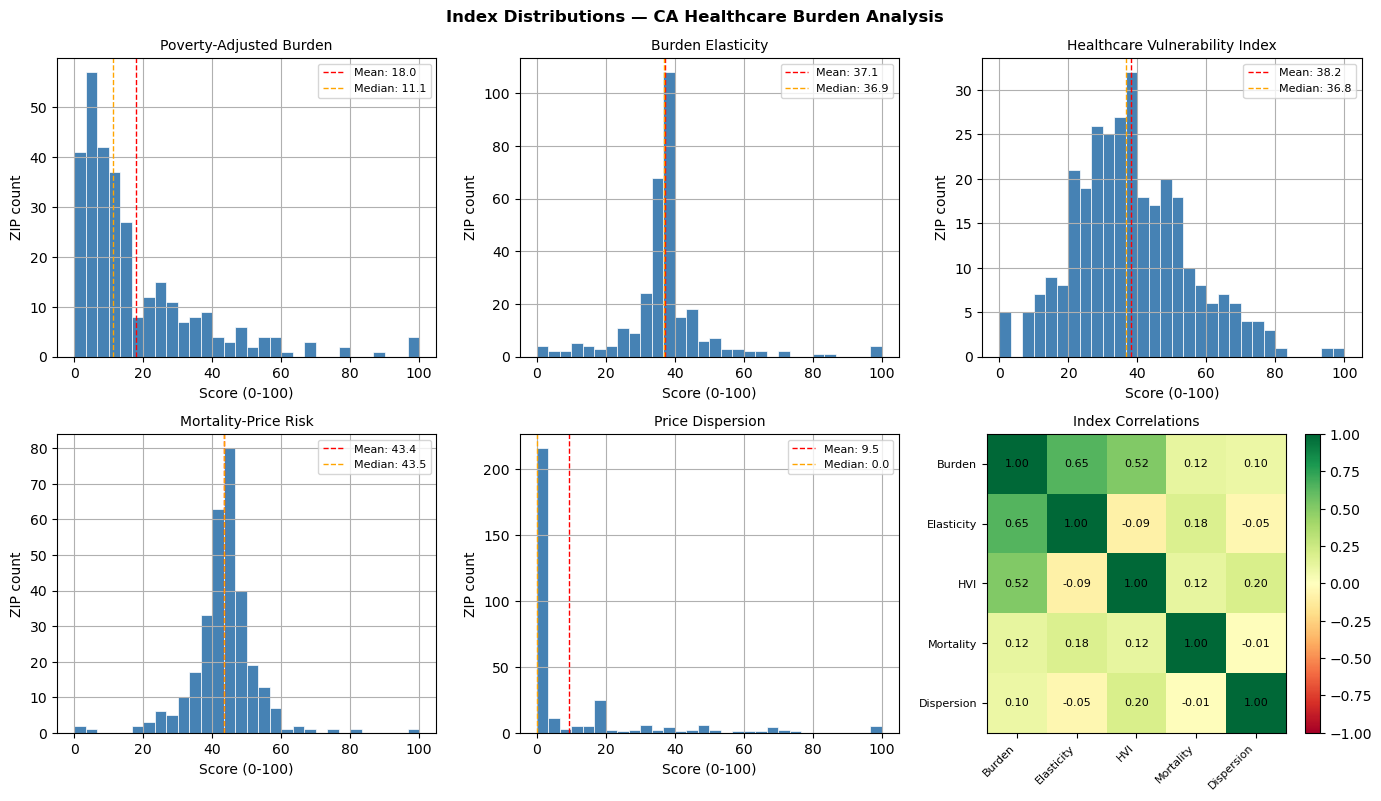

✓ Saved: output_index_distributions.png

Index correlation matrix:
                       idx_poverty_burden  idx_burden_elasticity  idx_hvi  idx_mortality_risk  idx_price_dispersion
idx_poverty_burden                  1.000                  0.645    0.515               0.119                 0.100
idx_burden_elasticity               0.645                  1.000   -0.088               0.183                -0.050
idx_hvi                             0.515                 -0.088    1.000               0.124                 0.199
idx_mortality_risk                  0.119                  0.183    0.124               1.000                -0.012
idx_price_dispersion                0.100                 -0.050    0.199              -0.012                 1.000


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Index Distributions — CA Healthcare Burden Analysis', fontweight='bold')

index_cols = {
    'idx_poverty_burden': 'Poverty-Adjusted Burden',
    'idx_burden_elasticity': 'Burden Elasticity', 
    'idx_hvi': 'Healthcare Vulnerability Index',
    'idx_mortality_risk': 'Mortality-Price Risk',
    'idx_price_dispersion': 'Price Dispersion',
}

for ax, (col, label) in zip(axes.flatten(), index_cols.items()):
    df_idx[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(df_idx[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df_idx[col].mean():.1f}')
    ax.axvline(df_idx[col].median(), color='orange', linestyle='--', linewidth=1, label=f'Median: {df_idx[col].median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0-100)')
    ax.set_ylabel('ZIP count')
    ax.legend(fontsize=8)

# Correlation heatmap in last panel
import numpy as np
corr = df_idx[list(index_cols.keys())].corr()
im = axes[1,2].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1,2].set_xticks(range(len(index_cols)))
axes[1,2].set_yticks(range(len(index_cols)))
short_labels = ['Burden', 'Elasticity', 'HVI', 'Mortality', 'Dispersion']
axes[1,2].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[1,2].set_yticklabels(short_labels, fontsize=8)
for i in range(len(index_cols)):
    for j in range(len(index_cols)):
        axes[1,2].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
axes[1,2].set_title('Index Correlations', fontsize=10)
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.savefig(BASE_DIR / 'output_index_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: output_index_distributions.png")

# Also print correlation table cleanly
print("\nIndex correlation matrix:")
print(corr.round(3).to_string())

---
## Block 7 — Regression analysis
**Goal**: Three regression models:
1. **OLS baseline** — log(avg_price) ~ poverty + uninsured + elderly + disability
2. **HVI components model** — tests each vulnerability dimension's price association
3. **Mortality outcome model** — deaths_per_100k ~ avg_price + poverty + uninsured

All models use robust standard errors (HC3). Results saved to `output_regression_results.csv`.

Block 7 — Regression Analysis
│
├── 7.1  Price models (what drives chargemaster prices?)
│         Model 1: Log(price) ~ vulnerability components    ← already done
│         Model 2: Log(price) ~ HVI composite               ← already done
│         Model 4a: Emergency price ~ vulnerability         ← already done
│         Model 4b: Delivery price ~ vulnerability          ← already done, noted as underpowered
│
├── 7.2  Mortality — raw model + confounding diagnosis
│         Model 3 original: deaths/100k ~ price + poverty   ← already done
│         Robustness check: bivariate correlations          ← just ran this
│         Finding: age + healthy immigrant effect confound raw mortality
│
└── 7.3  Mortality respecified (age-adjusted excess mortality)
          Model 3 respec: adj_mortality ~ price + vulnerability  ← run next
          Model 3b: adj_mortality ~ HVI                          ← run next
          Model 3c: adj_mortality ~ poverty burden index         ← run next

In [9]:
# ── Block 7.1 — Price Models ──────────────────────────────────────────────────
# Goal: What drives chargemaster prices at ZIP level?
# Models:
#   M1  : Log(price) ~ vulnerability components (poverty, uninsured, elderly,
#          disability, income) — tests whether community need predicts price
#   M2  : Log(price) ~ HVI composite + n_hospitals — tests composite index
#          and supply-side competition effect
#   M4a : Log(emergency price) ~ vulnerability — ED-specific price drivers
#   M4b : Log(delivery price) ~ vulnerability — OB-specific (n=64, underpowered)
# All models use HC3 robust standard errors.
# Key finding preview: income drives prices, not community need. More hospital
# competition associates with HIGHER prices (no market discipline on chargemaster).

from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

# ── Working dataset ───────────────────────────────────────────────────────────
reg_vars = [
    "zip", "log_avg_price_all", "avg_price_all",
    "log_avg_price_emerg", "log_avg_price_deliv",
    "poverty_rate", "pct_uninsured", "pct_elderly", "pct_disability",
    "median_income", "log_median_income",
    "deaths_per_100k", "mortality_age_adj_proxy",
    "idx_hvi", "idx_poverty_burden",
    "n_hospitals_zip", "n_cpt_codes"
]
reg_vars = [v for v in reg_vars if v in df_idx.columns]
df_reg = df_idx[reg_vars].dropna(
    subset=["log_avg_price_all", "poverty_rate", "pct_uninsured",
            "pct_elderly", "pct_disability", "median_income"]
).copy()

# Convert rates to percentages for interpretable coefficients
for col in ["poverty_rate", "pct_uninsured", "pct_elderly", "pct_disability"]:
    df_reg[col + "_pct"] = df_reg[col] * 100

print(f"Block 7.1 regression sample: {len(df_reg):,} ZIPs")
all_results = []

# ── Model 1: Log(price) ~ vulnerability components ───────────────────────────
m1 = smf.ols(
    "log_avg_price_all ~ poverty_rate_pct + pct_uninsured_pct "
    "+ pct_elderly_pct + pct_disability_pct + log_median_income",
    data=df_reg
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 1: Log(Price) ~ Vulnerability Components (HC3 SE)")
print("="*60)
print(m1.summary())
res1 = m1.summary2().tables[1].copy()
res1.insert(0, "model", "M1_price_vulnerability")
all_results.append(res1)

# ── Model 2: Log(price) ~ HVI composite ──────────────────────────────────────
m2 = smf.ols(
    "log_avg_price_all ~ idx_hvi + n_hospitals_zip",
    data=df_reg
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 2: Log(Price) ~ HVI Composite + Hospital Competition (HC3 SE)")
print("="*60)
print(m2.summary())
res2 = m2.summary2().tables[1].copy()
res2.insert(0, "model", "M2_price_hvi")
all_results.append(res2)

# ── Model 4a: Emergency price ~ vulnerability ─────────────────────────────────
df_emerg = df_reg.dropna(subset=["log_avg_price_emerg"]).copy()
m4a = smf.ols(
    "log_avg_price_emerg ~ poverty_rate_pct + pct_uninsured_pct "
    "+ pct_elderly_pct + log_median_income",
    data=df_emerg
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 4a: Log(Emergency Price) ~ Vulnerability (HC3 SE)")
print("="*60)
print(m4a.summary())
res4a = m4a.summary2().tables[1].copy()
res4a.insert(0, "model", "M4a_emergency_price")
all_results.append(res4a)

# ── Model 4b: Delivery price ~ vulnerability (underpowered, n=64) ─────────────
df_deliv = df_reg.dropna(subset=["log_avg_price_deliv"]).copy()
print(f"\nDelivery sample: {len(df_deliv):,} ZIPs (underpowered — report as exploratory)")
m4b = smf.ols(
    "log_avg_price_deliv ~ poverty_rate_pct + pct_uninsured_pct "
    "+ pct_elderly_pct + log_median_income",
    data=df_deliv
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 4b: Log(Delivery Price) ~ Vulnerability (HC3 SE, n=64)")
print("="*60)
print(m4b.summary())
res4b = m4b.summary2().tables[1].copy()
res4b.insert(0, "model", "M4b_delivery_price_exploratory")
all_results.append(res4b)

print("\n✓ Block 7.1 complete")

Block 7.1 regression sample: 308 ZIPs

MODEL 1: Log(Price) ~ Vulnerability Components (HC3 SE)
                            OLS Regression Results                            
Dep. Variable:      log_avg_price_all   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     9.328
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.82e-08
Time:                        16:40:43   Log-Likelihood:                -183.93
No. Observations:                 308   AIC:                             379.9
Df Residuals:                     302   BIC:                             402.2
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

In [10]:
# ── Block 7.2 — Mortality Confounding Diagnosis ───────────────────────────────
# Goal: Test whether raw all-cause mortality is a valid outcome for measuring
# healthcare access burden in CA. Two confounders hypothesized:
#   1. Age structure — elderly ZIPs have high mortality by demographics alone
#   2. Healthy immigrant effect — uninsured ZIPs in CA skew young/immigrant
#      with low mortality despite poor access (Hispanic Paradox literature)
# Method: bivariate correlations + original Model 3 + alt spec without elderly
# Conclusion: raw mortality is the WRONG outcome for this analysis in CA.
#   Both confounders confirmed. See Block 7.3 for corrected specification.

print("="*60)
print("BLOCK 7.2: Mortality Confounding Diagnosis")
print("="*60)

# ── Bivariate correlations ────────────────────────────────────────────────────
print("\nBivariate correlations with raw deaths_per_100k:")
mort_corr = df_idx[[
    'deaths_per_100k', 'pct_uninsured', 'pct_elderly',
    'median_income', 'poverty_rate', 'avg_price_all',
    'idx_hvi', 'idx_poverty_burden'
]].corr()['deaths_per_100k'].round(3)
print(mort_corr)

print("\nInterpretation:")
print(f"  pct_elderly  r={mort_corr['pct_elderly']:.3f}  → age structure dominates raw mortality")
print(f"  pct_uninsured r={mort_corr['pct_uninsured']:.3f} → negative: healthy immigrant effect (Hispanic Paradox)")
print(f"  avg_price_all r={mort_corr['avg_price_all']:.3f} → negative: price proxies market wealth, not burden")
print(f"  poverty_rate  r={mort_corr['poverty_rate']:.3f}  → near zero: poverty doesn't predict raw mortality")

# ── Original Model 3 (retained for transparency) ──────────────────────────────
df_mort_reg = df_reg.dropna(subset=["deaths_per_100k"]).copy()
m3_original = smf.ols(
    "deaths_per_100k ~ avg_price_all + poverty_rate_pct "
    "+ pct_uninsured_pct + pct_elderly_pct + log_median_income",
    data=df_mort_reg
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 3 ORIGINAL: Deaths/100k ~ Price + Vulnerability")
print("(Retained for transparency — confounded, not used in final results)")
print("="*60)
print(m3_original.summary())
res3_orig = m3_original.summary2().tables[1].copy()
res3_orig.insert(0, "model", "M3_original_confounded_DO_NOT_USE")
all_results.append(res3_orig)

# ── Robustness: remove elderly control ───────────────────────────────────────
m3_alt = smf.ols(
    "deaths_per_100k ~ avg_price_all + poverty_rate_pct "
    "+ pct_uninsured_pct + log_median_income",
    data=df_mort_reg
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 3 ALT: Deaths/100k ~ Price + Vulnerability (no elderly control)")
print("(Robustness check — confirms misspecification without age control)")
print("="*60)
print(m3_alt.summary().tables[1])

print("\n✓ Block 7.2 complete — raw mortality confirmed as invalid outcome")
print("  Proceed to Block 7.3 for age-adjusted respecification")

BLOCK 7.2: Mortality Confounding Diagnosis

Bivariate correlations with raw deaths_per_100k:
deaths_per_100k       1.000
pct_uninsured        -0.287
pct_elderly           0.761
median_income        -0.238
poverty_rate          0.055
avg_price_all        -0.200
idx_hvi               0.532
idx_poverty_burden   -0.028
Name: deaths_per_100k, dtype: float64

Interpretation:
  pct_elderly  r=0.761  → age structure dominates raw mortality
  pct_uninsured r=-0.287 → negative: healthy immigrant effect (Hispanic Paradox)
  avg_price_all r=-0.200 → negative: price proxies market wealth, not burden
  poverty_rate  r=0.055  → near zero: poverty doesn't predict raw mortality

MODEL 3 ORIGINAL: Deaths/100k ~ Price + Vulnerability
(Retained for transparency — confounded, not used in final results)
                            OLS Regression Results                            
Dep. Variable:        deaths_per_100k   R-squared:                       0.698
Model:                            OLS   Adj. R-sq

In [11]:
# ── Block 7.3 — Mortality Respecified (Age-Adjusted Excess Mortality) ─────────
# Goal: Replace raw mortality with age-adjusted excess mortality proxy.
# Proxy: mortality_age_adj_proxy = deaths_per_100k / (pct_elderly × 100)
#   Interpretation: deaths relative to what community age structure predicts.
#   High score = more deaths than demographics expect = healthcare access failure.
#   Confirmed in Block 6: proxy correlates +0.378 with HVI (vs -0.195 raw)
#   and +0.508 with poverty burden — meaningful and directionally correct.
# Three models tested:
#   M3_respec : full spec — price + all vulnerability components
#   M3b       : HVI as single composite predictor
#   M3c       : poverty burden index as predictor (strongest index correlation)

print("="*60)
print("BLOCK 7.3: Age-Adjusted Excess Mortality Models")
print("="*60)

# ── Working dataset ───────────────────────────────────────────────────────────
df_reg_adj = df_idx[[
    'mortality_age_adj_proxy', 'avg_price_all', 'poverty_rate',
    'pct_uninsured', 'pct_disability', 'pct_elderly',
    'log_median_income', 'idx_hvi', 'idx_poverty_burden'
]].copy()
df_reg_adj['poverty_rate_pct']   = df_reg_adj['poverty_rate'] * 100
df_reg_adj['pct_uninsured_pct']  = df_reg_adj['pct_uninsured'] * 100
df_reg_adj['pct_disability_pct'] = df_reg_adj['pct_disability'] * 100
df_reg_adj['pct_elderly_pct']    = df_reg_adj['pct_elderly'] * 100
df_reg_adj = df_reg_adj.dropna()
print(f"Age-adjusted mortality regression sample: {len(df_reg_adj):,} ZIPs")

# ── Bivariate correlations with proxy ────────────────────────────────────────
print("\nBivariate correlations with age-adjusted mortality proxy:")
adj_corr = df_reg_adj[[
    'mortality_age_adj_proxy', 'pct_uninsured', 'pct_elderly',
    'median_income' if 'median_income' in df_reg_adj.columns else 'log_median_income',
    'poverty_rate', 'avg_price_all', 'idx_hvi', 'idx_poverty_burden'
]].corr()['mortality_age_adj_proxy'].round(3)
print(adj_corr)

# ── Model 3 respecified: full vulnerability spec ──────────────────────────────
m3_respec = smf.ols(
    "mortality_age_adj_proxy ~ avg_price_all + poverty_rate_pct "
    "+ pct_uninsured_pct + pct_disability_pct + log_median_income",
    data=df_reg_adj
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 3 RESPEC: Age-Adjusted Mortality ~ Price + Vulnerability (HC3 SE)")
print("="*60)
print(m3_respec.summary())
res3_respec = m3_respec.summary2().tables[1].copy()
res3_respec.insert(0, "model", "M3_respec_age_adj_mortality")
all_results.append(res3_respec)

# ── Model 3b: HVI as single predictor ────────────────────────────────────────
m3b = smf.ols(
    "mortality_age_adj_proxy ~ idx_hvi",
    data=df_reg_adj
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 3b: Age-Adjusted Mortality ~ HVI Composite (HC3 SE)")
print("="*60)
print(m3b.summary())
res3b = m3b.summary2().tables[1].copy()
res3b.insert(0, "model", "M3b_adj_mortality_hvi")
all_results.append(res3b)

# ── Model 3c: Poverty burden index as predictor ───────────────────────────────
m3c = smf.ols(
    "mortality_age_adj_proxy ~ idx_poverty_burden",
    data=df_reg_adj
).fit(cov_type="HC3")
print("\n" + "="*60)
print("MODEL 3c: Age-Adjusted Mortality ~ Poverty Burden Index (HC3 SE)")
print("="*60)
print(m3c.summary())
res3c = m3c.summary2().tables[1].copy()
res3c.insert(0, "model", "M3c_adj_mortality_burden")
all_results.append(res3c)

print("\n✓ Block 7.3 complete")

BLOCK 7.3: Age-Adjusted Excess Mortality Models
Age-adjusted mortality regression sample: 308 ZIPs

Bivariate correlations with age-adjusted mortality proxy:
mortality_age_adj_proxy    1.000
pct_uninsured              0.411
pct_elderly               -0.381
log_median_income         -0.550
poverty_rate               0.469
avg_price_all              0.004
idx_hvi                    0.358
idx_poverty_burden         0.508
Name: mortality_age_adj_proxy, dtype: float64

MODEL 3 RESPEC: Age-Adjusted Mortality ~ Price + Vulnerability (HC3 SE)
                               OLS Regression Results                              
Dep. Variable:     mortality_age_adj_proxy   R-squared:                       0.357
Model:                                 OLS   Adj. R-squared:                  0.347
Method:                      Least Squares   F-statistic:                     26.19
Date:                     Sun, 19 Apr 2026   Prob (F-statistic):           5.74e-22
Time:                             16:40

In [12]:
# ── Block 7.4 — Save All Regression Results ───────────────────────────────────
# Goal: Compile all model results into a single CSV for reporting.
# Includes all models from 7.1, 7.2, 7.3 with clear model labels.
# M3_original flagged DO_NOT_USE — retained for methods transparency only.

df_regs_all = pd.concat(all_results, ignore_index=True)
df_regs_all.to_csv(OUT_REGRESSION, index=False)
print(f"✓ All regression results saved: {OUT_REGRESSION}")
print(f"  Models saved: {df_regs_all['model'].unique().tolist()}")

# ── Regression summary table (publication-ready) ─────────────────────────────
print("\n" + "="*60)
print("REGRESSION SUMMARY — KEY COEFFICIENTS")
print("="*60)

summary_rows = []
models = {
    "M1 Price~Vulnerability": m1,
    "M2 Price~HVI":           m2,
    "M4a EmergPrice~Vuln":    m4a,
    "M3r AdjMort~Vuln":       m3_respec,
    "M3b AdjMort~HVI":        m3b,
    "M3c AdjMort~Burden":     m3c,
}
for name, model in models.items():
    row = {
        "model":       name,
        "n":           int(model.nobs),
        "r_squared":   round(model.rsquared, 3),
        "adj_r2":      round(model.rsquared_adj, 3),
        "f_pvalue":    f"{model.f_pvalue:.4f}",
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# ── Save summary ──────────────────────────────────────────────────────────────
summary_path = BASE_DIR / "output_regression_summary.csv"
df_summary.to_csv(summary_path, index=False)
print(f"\n✓ Regression summary saved: {summary_path}")
print("\nReady for Block 8 — final outputs")

✓ All regression results saved: C:\Users\Parvati\Downloads\output_regression_results.csv
  Models saved: ['M1_price_vulnerability', 'M2_price_hvi', 'M4a_emergency_price', 'M4b_delivery_price_exploratory', 'M3_original_confounded_DO_NOT_USE', 'M3_respec_age_adj_mortality', 'M3b_adj_mortality_hvi', 'M3c_adj_mortality_burden']

REGRESSION SUMMARY — KEY COEFFICIENTS


,model,n,r_squared,adj_r2,f_pvalue
0,M1 Price~Vulnerability,308,0.146,0.132,0.0000
1,M2 Price~HVI,308,0.094,0.089,0.0000
2,M4a EmergPrice~Vuln,308,0.149,0.137,0.0000
3,M3r AdjMort~Vuln,308,0.357,0.347,0.0000
4,M3b AdjMort~HVI,308,0.128,0.125,0.0000
5,M3c AdjMort~Burden,308,0.258,0.255,0.0000



✓ Regression summary saved: C:\Users\Parvati\Downloads\output_regression_summary.csv

Ready for Block 8 — final outputs


In [13]:
# ── Add effect size interpretation to summary ─────────────────────────────────
effect_notes = {
    "M1 Price~Vulnerability":  "Income drives price (+0.54 log pts per log income, p=0.001)",
    "M2 Price~HVI":            "HVI sig but weak; competition raises prices (p=0.034)",
    "M4a EmergPrice~Vuln":     "Mirrors M1; elderly negative (-0.021, p<0.001)",
    "M3r AdjMort~Vuln":        "Price sig after age-adj (+0.0017, p<0.001); uninsured +0.74",
    "M3b AdjMort~HVI":         "HVI predicts excess mortality (+0.269/10pts, p<0.001)",
    "M3c AdjMort~Burden":      "Burden index strongest predictor (+0.339/10pts, p<0.001)",
}
df_summary["key_finding"] = df_summary["model"].map(effect_notes)
df_summary.to_csv(BASE_DIR / "output_regression_summary.csv", index=False)
print("✓ Summary updated with key findings")
display(df_summary)

✓ Summary updated with key findings


,model,n,r_squared,adj_r2,f_pvalue,key_finding
0,M1 Price~Vulnerability,308,0.146,0.132,0.0000,Income drives price (+0.54 log pts per log inc...
1,M2 Price~HVI,308,0.094,0.089,0.0000,HVI sig but weak; competition raises prices (p...
2,M4a EmergPrice~Vuln,308,0.149,0.137,0.0000,"Mirrors M1; elderly negative (-0.021, p<0.001)"
3,M3r AdjMort~Vuln,308,0.357,0.347,0.0000,"Price sig after age-adj (+0.0017, p<0.001); un..."
4,M3b AdjMort~HVI,308,0.128,0.125,0.0000,"HVI predicts excess mortality (+0.269/10pts, p..."
5,M3c AdjMort~Burden,308,0.258,0.255,0.0000,Burden index strongest predictor (+0.339/10pts...


---
## Block 8 — Summary outputs & export
**Goal**: Generate final analysis outputs:
- Top 25 highest-burden ZIPs (policy target list)
- Full analysis dataset (all indexes + regression inputs)
- Summary statistics by HVI quintile
- Top CPT codes driving burden

In [14]:
# ── Output 1: Full analysis dataset ──────────────────────────────────────────
df_idx.to_csv(OUT_FULL, index=False)
print(f"✓ Full dataset saved: {OUT_FULL} ({len(df_idx):,} ZIPs, {len(df_idx.columns)} columns)")

# ── Output 2: Top 25 burden ZIPs (policy target list) ────────────────────────
report_cols = [
    "zip", "idx_hvi", "hvi_quintile", "idx_poverty_burden",
    "idx_mortality_risk", "idx_price_dispersion",
    "avg_price_all", "avg_price_emerg", "avg_price_deliv",
    "median_income", "poverty_rate", "pct_uninsured",
    "pct_elderly", "pct_disability",
    "deaths_per_100k", "total_pop", "n_hospitals_zip"
]
report_cols = [c for c in report_cols if c in df_idx.columns]

df_top = (
    df_idx[report_cols]
    .dropna(subset=["idx_hvi"])
    .sort_values("idx_hvi", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
df_top.index += 1  # rank from 1
df_top.to_csv(OUT_TOP_BURDEN, index=True, index_label="rank")
print(f"✓ Top 25 burden ZIPs saved: {OUT_TOP_BURDEN}")

# ── Display top ZIPs ──────────────────────────────────────────────────────────
print("\n📋 Top 25 Highest Healthcare Vulnerability ZIPs (CA, 2024):")
display_cols = ["zip", "idx_hvi", "avg_price_all", "median_income",
                "poverty_rate", "pct_uninsured", "deaths_per_100k"]
display_cols = [c for c in display_cols if c in df_top.columns]
display(df_top[display_cols].round(2))

# ── Output 3: Summary by HVI quintile ────────────────────────────────────────
print("\n📊 Key metrics by HVI quintile:")
quintile_summary = (
    df_idx.groupby("hvi_quintile", observed=True)[[  
        "avg_price_all", "avg_price_emerg", "avg_price_deliv",
        "median_income", "poverty_rate", "pct_uninsured",
        "pct_elderly", "pct_disability", "deaths_per_100k"
    ]].mean().round(2)
)
display(quintile_summary)

# ── Output 4: Top CPT codes by burden (ZIP × CPT level) ──────────────────────
print("\n📋 Top CPT codes by average burden score:")

# Pull only what's needed from df_zip (confirmed column source)
zip_burden_lookup = df_zip[["zip", "poverty_rate", "median_income", "idx_hvi"]].copy() \
    if "idx_hvi" in df_zip.columns \
    else df_idx[["zip", "poverty_rate", "median_income", "idx_hvi"]].copy()

# Merge carefully with suffix handling
df_cpt_burden = df_cpt.merge(zip_burden_lookup, on="zip", how="left", suffixes=("", "_zip"))

# Use whichever median_income column landed
med_inc_col = "median_income" if "median_income" in df_cpt_burden.columns else "median_income_zip"
pov_col     = "poverty_rate"  if "poverty_rate"  in df_cpt_burden.columns else "poverty_rate_zip"

df_cpt_burden["cpt_burden"] = (
    df_cpt_burden["avg_price"] / df_cpt_burden[med_inc_col]
) * df_cpt_burden[pov_col]

top_cpts = (
    df_cpt_burden.groupby(["procedure_code", "cpt_group"])
    .agg(
        avg_price  = ("avg_price",   "mean"),
        avg_burden = ("cpt_burden",  "mean"),
        n_zips     = ("zip",         "nunique")
    )
    .sort_values("avg_burden", ascending=False)
    .head(15)
    .reset_index()
)
display(top_cpts.round(4))

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"  Full dataset    : {OUT_FULL}")
print(f"  Top burden ZIPs : {OUT_TOP_BURDEN}")
print(f"  Regression table: {OUT_REGRESSION}")
print(f"  ZIPs analyzed   : {len(df_idx):,}")
print(f"  Hospitals       : {df_charge['hospital'].nunique()}")
print(f"  CPT codes       : {df_charge['procedure_code'].nunique()}")

✓ Full dataset saved: C:\Users\Parvati\Downloads\output_full_analysis_dataset.csv (308 ZIPs, 43 columns)
✓ Top 25 burden ZIPs saved: C:\Users\Parvati\Downloads\output_top_burden_zips.csv

📋 Top 25 Highest Healthcare Vulnerability ZIPs (CA, 2024):


,zip,idx_hvi,avg_price_all,median_income,poverty_rate,pct_uninsured,deaths_per_100k
1,92363,100.00,1470.00,40068.0,0.29,0.11,1554.87
2,95249,95.77,1573.75,45302.0,0.30,0.04,1909.20
3,93545,81.41,1169.75,43529.0,0.24,0.06,1496.60
4,92252,78.76,3319.58,66598.0,0.22,0.09,1618.47
5,95457,78.30,3092.26,63594.0,0.15,0.12,1121.08
6,96101,77.56,1014.51,61680.0,0.20,0.10,1341.89
7,95542,75.81,1098.14,46104.0,0.32,0.03,1380.43
8,92220,75.59,3110.38,62599.0,0.19,0.07,1460.52
9,95422,74.07,3092.26,42241.0,0.25,0.08,1424.89
10,96093,73.51,1494.75,65741.0,0.17,0.04,810.19



📊 Key metrics by HVI quintile:


,avg_price_all,avg_price_emerg,avg_price_deliv,median_income,poverty_rate,pct_uninsured,pct_elderly,pct_disability,deaths_per_100k
hvi_quintile,,,,,,,,,
Very Low,3679.15,3670.41,4596.33,139033.89,0.07,0.04,0.16,0.09,680.97
Low,3449.76,3432.95,3939.23,111882.64,0.09,0.05,0.18,0.11,753.59
Moderate,3136.20,3091.87,3865.62,90624.76,0.14,0.07,0.16,0.12,794.85
High,2825.17,2759.92,4328.88,77976.34,0.16,0.08,0.17,0.14,852.29
Very High,2689.64,2588.98,3377.40,63060.05,0.20,0.08,0.22,0.18,1124.52



📋 Top CPT codes by average burden score:


,procedure_code,cpt_group,avg_price,avg_burden,n_zips
0,99291,emergency,6453.9457,0.0166,83
1,59510,delivery,5507.1454,0.0158,38
2,59400,delivery,4965.5504,0.0139,40
3,59515,delivery,4450.7200,0.0133,1
4,99285,emergency,5329.9210,0.0087,261
5,59409,delivery,3025.5578,0.0072,63
6,59410,delivery,4915.0000,0.0065,2
7,99292,emergency,2714.1746,0.0062,92
8,99284,emergency,3714.7923,0.0058,307
9,59514,delivery,2154.4067,0.0055,43



ANALYSIS COMPLETE
  Full dataset    : C:\Users\Parvati\Downloads\output_full_analysis_dataset.csv
  Top burden ZIPs : C:\Users\Parvati\Downloads\output_top_burden_zips.csv
  Regression table: C:\Users\Parvati\Downloads\output_regression_results.csv
  ZIPs analyzed   : 308
  Hospitals       : 348
  CPT codes       : 13


In [48]:
import sys
!{sys.executable} -m pip install geopandas mapclassify --quiet
print("✓ Done")

✓ Done



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ Shapefile found: C:\Users\Parvati\Downloads\zcta_shapefile\tl_2023_us_zcta520.shp
Loading shapefile...
  CA ZIPs in shapefile: 308
  Joined ZIPs: 308 with HVI data


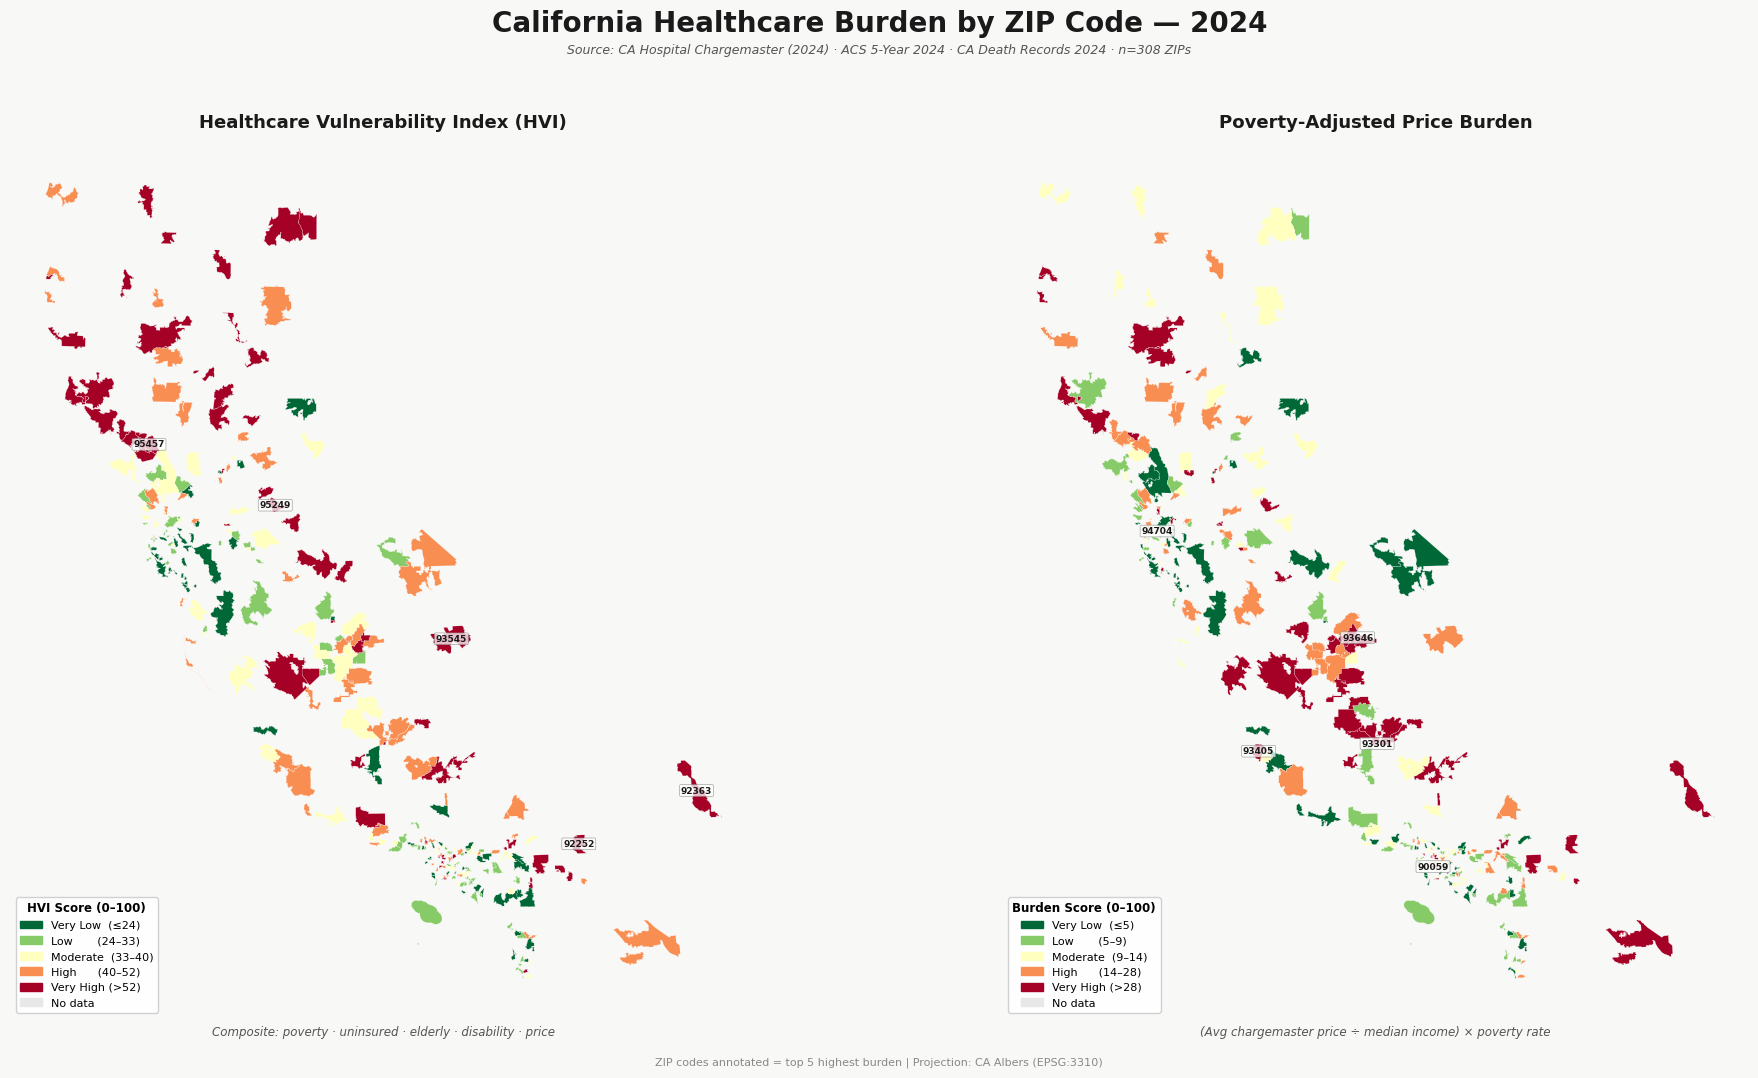

✓ Map saved: C:\Users\Parvati\Downloads\output_choropleth_hvi_burden.png
  Ready for presentation slides


In [15]:
# ── Block 9 — Choropleth Maps ─────────────────────────────────────────────────
# Goal: Produce publication-quality choropleth maps of CA ZIPs for presentation.
# Maps produced:
#   1. Healthcare Vulnerability Index (HVI) — composite flagship
#   2. Poverty-Adjusted Price Burden — financial impact index
# Format: high-res PNG (300dpi), side-by-side, diverging green→yellow→red
# Requires: geopandas, matplotlib, mapclassify
# Install if needed:
#   pip install geopandas mapclassify
#   ZCTA shapefile auto-downloaded from Census TIGER if not cached locally

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import mapclassify
import urllib.request
import zipfile
import os

# ── Shapefile setup ───────────────────────────────────────────────────────────
# Census TIGER 2023 ZCTA shapefile — auto-download if not cached
SHAPEFILE_DIR  = BASE_DIR / "zcta_shapefile"
SHAPEFILE_PATH = SHAPEFILE_DIR / "tl_2023_us_zcta520.shp"
SHAPEFILE_URL  = "https://www2.census.gov/geo/tiger/TIGER2023/ZCTA520/tl_2023_us_zcta520.zip"

if not SHAPEFILE_PATH.exists():
    print("Downloading Census ZCTA shapefile (~170MB)...")
    SHAPEFILE_DIR.mkdir(exist_ok=True)
    zip_path = SHAPEFILE_DIR / "zcta.zip"
    urllib.request.urlretrieve(SHAPEFILE_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(SHAPEFILE_DIR)
    os.remove(zip_path)
    print(f"✓ Shapefile extracted: {SHAPEFILE_DIR}")
else:
    print(f"✓ Shapefile found: {SHAPEFILE_PATH}")

# ── Load and filter to CA ZIPs ────────────────────────────────────────────────
print("Loading shapefile...")
gdf = gpd.read_file(SHAPEFILE_PATH)
gdf = gdf.rename(columns={"ZCTA5CE20": "zip"})

# Filter to CA ZIPs in our analysis dataset
ca_zips = set(df_idx["zip"].astype(str).str.zfill(5))
gdf = gdf[gdf["zip"].isin(ca_zips)].copy()
print(f"  CA ZIPs in shapefile: {len(gdf):,}")

# ── Join index data ───────────────────────────────────────────────────────────
map_data = df_idx[["zip", "idx_hvi", "idx_poverty_burden",
                    "hvi_quintile", "avg_price_all",
                    "median_income", "poverty_rate",
                    "pct_uninsured", "deaths_per_100k"]].copy()
map_data["zip"] = map_data["zip"].astype(str).str.zfill(5)
gdf = gdf.merge(map_data, on="zip", how="left")

# Project to California Albers (EPSG:3310) — correct projection for CA maps
gdf = gdf.to_crs(epsg=3310)
print(f"  Joined ZIPs: {gdf['idx_hvi'].notna().sum():,} with HVI data")

# ── Color setup ───────────────────────────────────────────────────────────────
CMAP = "RdYlGn_r"   # green=low burden, yellow=moderate, red=high burden
MISSING_COLOR = "#e8e8e8"
EDGE_COLOR    = "white"
EDGE_WIDTH    = 0.15

# ── Map configuration ─────────────────────────────────────────────────────────
maps = [
    {
        "col":      "idx_hvi",
        "title":    "Healthcare Vulnerability Index (HVI)",
        "subtitle": "Composite: poverty · uninsured · elderly · disability · price",
        "label":    "HVI Score (0–100)",
        "note":     "Higher = more vulnerable"
    },
    {
        "col":      "idx_poverty_burden",
        "title":    "Poverty-Adjusted Price Burden",
        "subtitle": "(Avg chargemaster price ÷ median income) × poverty rate",
        "label":    "Burden Score (0–100)",
        "note":     "Higher = greater financial burden"
    },
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(20, 11),
    facecolor="#f8f8f6"
)
fig.suptitle(
    "California Healthcare Burden by ZIP Code — 2024",
    fontsize=20, fontweight="bold", y=0.97, color="#1a1a1a"
)
fig.text(
    0.5, 0.93,
    "Source: CA Hospital Chargemaster (2024) · ACS 5-Year 2024 · CA Death Records 2024 · n=308 ZIPs",
    ha="center", fontsize=9, color="#555555", style="italic"
)

for ax, cfg in zip(axes, maps):
    col = cfg["col"]

    # ── Classify into quintiles for clean choropleth ──────────────────────────
    valid = gdf[col].dropna()
    classifier = mapclassify.Quantiles(valid, k=5)
    gdf[col + "_class"] = classifier.find_bin(gdf[col].fillna(-1))
    gdf.loc[gdf[col].isna(), col + "_class"] = -1

    # ── Color map ─────────────────────────────────────────────────────────────
    cmap = plt.cm.get_cmap(CMAP, 5)
    colors = [cmap(i / 4) for i in range(5)]

    # ── Plot missing ZIPs first ───────────────────────────────────────────────
    gdf[gdf[col].isna()].plot(
        ax=ax, color=MISSING_COLOR,
        edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH
    )

    # ── Plot each quintile ────────────────────────────────────────────────────
    for i, color in enumerate(colors):
        subset = gdf[gdf[col + "_class"] == i]
        if len(subset) > 0:
            subset.plot(
                ax=ax, color=color,
                edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH
            )

    # ── Top 5 highest burden ZIPs — annotate ─────────────────────────────────
    top5 = gdf.nlargest(5, col).copy()
    top5["centroid_x"] = top5.geometry.centroid.x
    top5["centroid_y"] = top5.geometry.centroid.y
    for _, row in top5.iterrows():
        ax.annotate(
            row["zip"],
            xy=(row["centroid_x"], row["centroid_y"]),
            fontsize=6.5, fontweight="bold", color="#1a1a1a",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white",
                      ec="#888888", alpha=0.75, lw=0.5)
        )

    # ── Titles ────────────────────────────────────────────────────────────────
    ax.set_title(
        cfg["title"], fontsize=13, fontweight="bold",
        pad=10, color="#1a1a1a"
    )
    ax.text(
        0.5, -0.02, cfg["subtitle"],
        transform=ax.transAxes, ha="center",
        fontsize=8.5, color="#555555", style="italic"
    )
    ax.axis("off")

    # ── Legend ────────────────────────────────────────────────────────────────
    breaks = classifier.bins
    labels = [
        f"Very Low  (≤{breaks[0]:.0f})",
        f"Low       ({breaks[0]:.0f}–{breaks[1]:.0f})",
        f"Moderate  ({breaks[1]:.0f}–{breaks[2]:.0f})",
        f"High      ({breaks[2]:.0f}–{breaks[3]:.0f})",
        f"Very High (>{breaks[3]:.0f})",
    ]
    patches = [
        mpatches.Patch(color=colors[i], label=labels[i])
        for i in range(5)
    ]
    patches.append(
        mpatches.Patch(color=MISSING_COLOR, label="No data")
    )
    legend = ax.legend(
        handles=patches,
        loc="lower left",
        fontsize=8,
        framealpha=0.9,
        edgecolor="#cccccc",
        title=cfg["label"],
        title_fontsize=8.5,
    )
    legend.get_title().set_fontweight("bold")

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    "ZIP codes annotated = top 5 highest burden | Projection: CA Albers (EPSG:3310)",
    ha="center", fontsize=8, color="#888888"
)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# ── Save ──────────────────────────────────────────────────────────────────────
OUT_MAP = BASE_DIR / "output_choropleth_hvi_burden.png"
plt.savefig(OUT_MAP, dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"✓ Map saved: {OUT_MAP}")
print("  Ready for presentation slides")

✓ County shapefile found


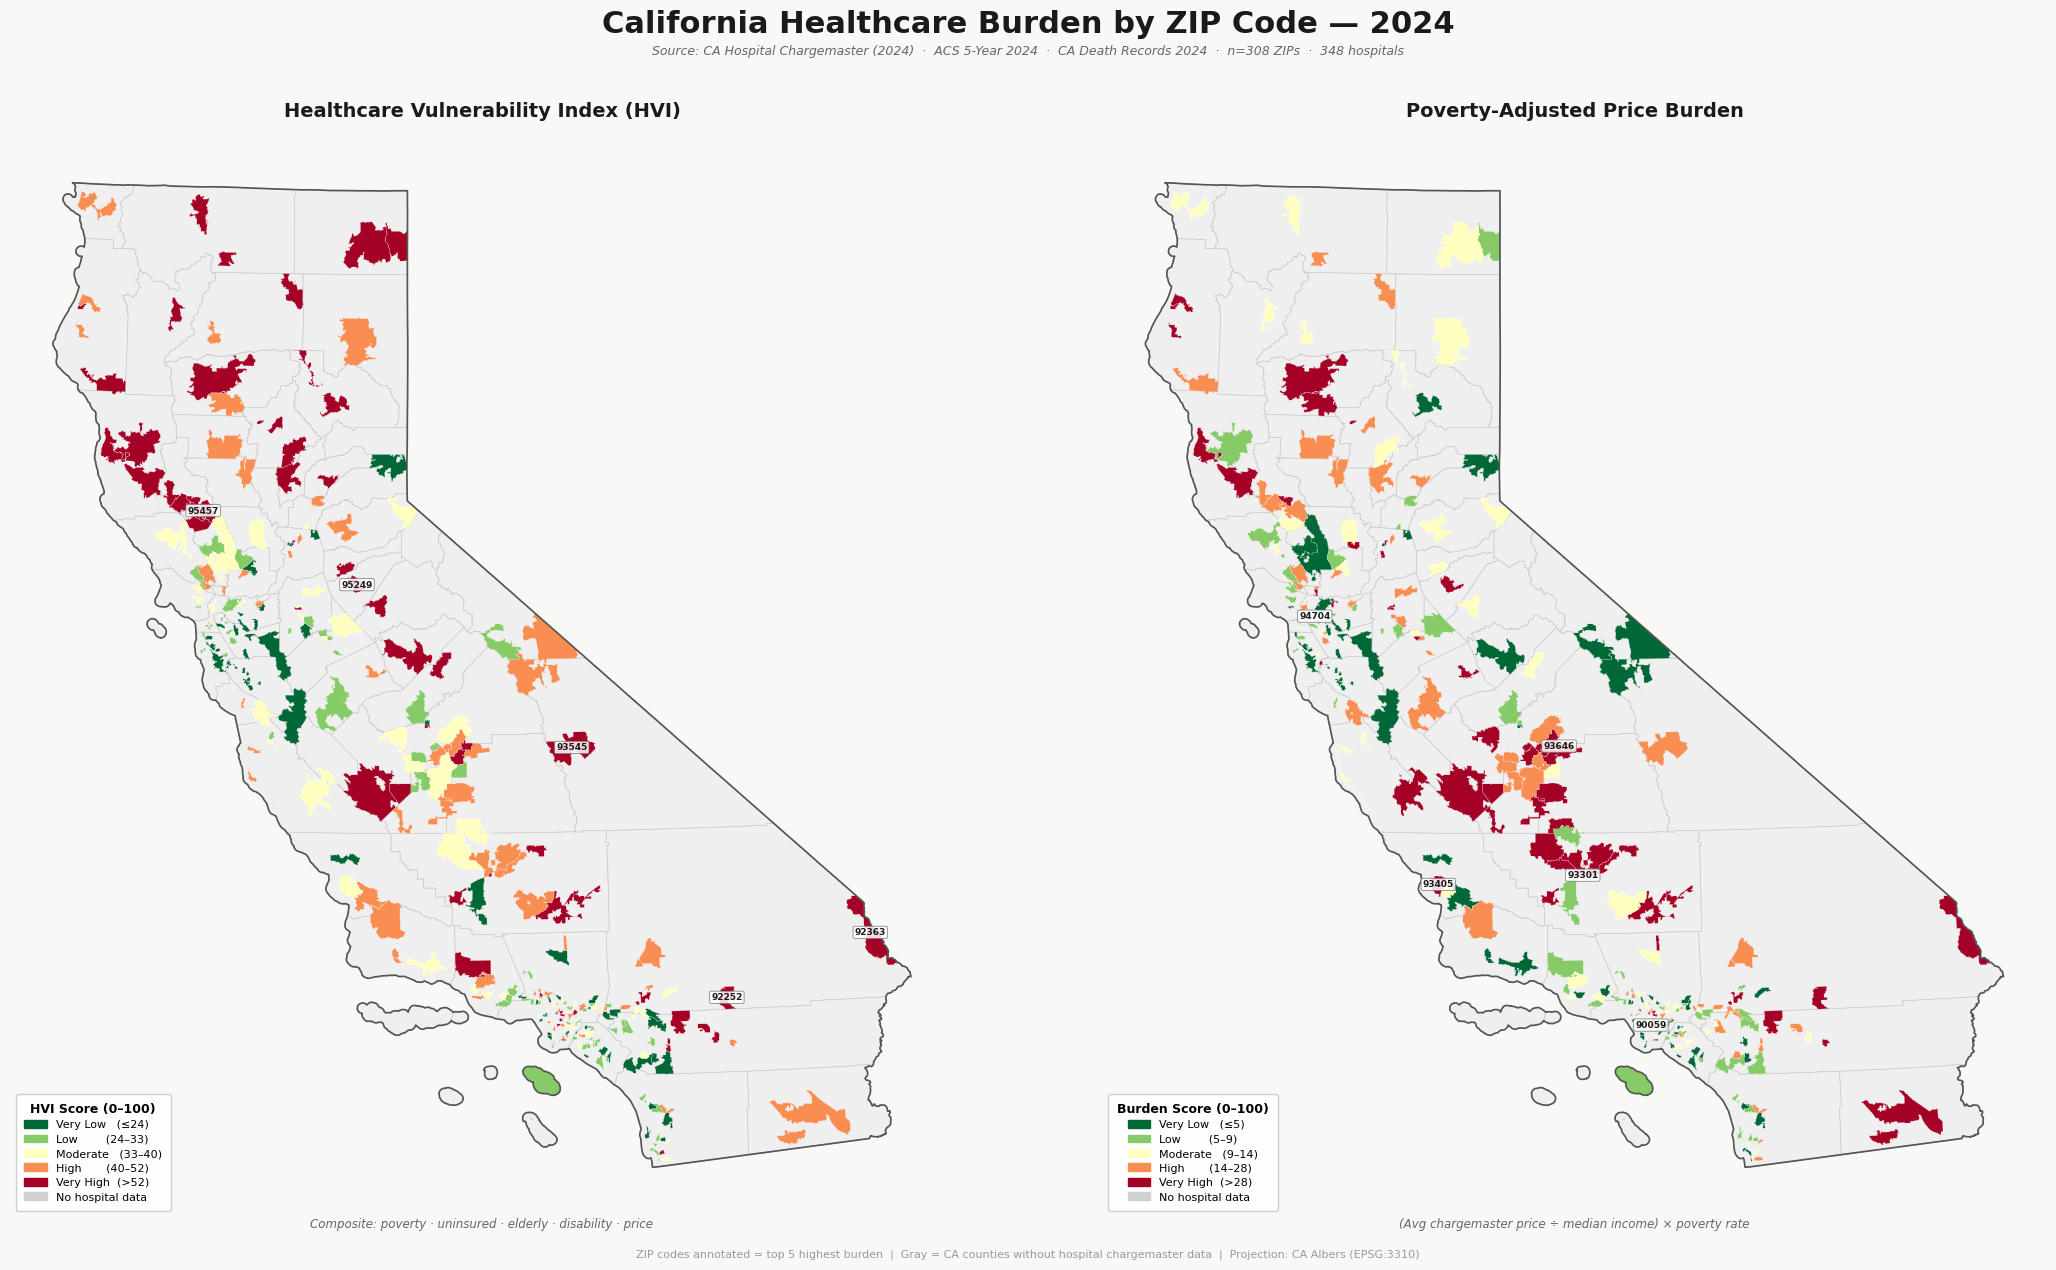

✓ Map saved: C:\Users\Parvati\Downloads\output_choropleth_hvi_burden_v2.png


In [16]:
# ── Block 9b — Choropleth with CA state background ───────────────────────────
# Fix: add CA county outlines as base layer so disconnected hospital ZIPs
# sit in geographic context. Downloads CA county shapefile from Census TIGER.

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import urllib.request, zipfile, os
import mapclassify

# ── Download CA county background shapefile ───────────────────────────────────
COUNTY_DIR  = BASE_DIR / "county_shapefile"
COUNTY_PATH = COUNTY_DIR / "tl_2023_us_county.shp"
COUNTY_URL  = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

if not COUNTY_PATH.exists():
    print("Downloading county shapefile (~130MB)...")
    COUNTY_DIR.mkdir(exist_ok=True)
    zip_path = COUNTY_DIR / "county.zip"
    urllib.request.urlretrieve(COUNTY_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(COUNTY_DIR)
    os.remove(zip_path)
    print("✓ County shapefile extracted")
else:
    print("✓ County shapefile found")

# ── Load and filter to CA only ────────────────────────────────────────────────
gdf_counties = gpd.read_file(COUNTY_PATH)
gdf_counties = gdf_counties[gdf_counties["STATEFP"] == "06"].copy()
gdf_counties = gdf_counties.to_crs(epsg=3310)

# CA state outline (dissolve all counties)
gdf_state = gdf_counties.dissolve()

# ── Reload ZIP shapefile (already downloaded) ─────────────────────────────────
gdf = gpd.read_file(SHAPEFILE_PATH)
gdf = gdf.rename(columns={"ZCTA5CE20": "zip"})
ca_zips = set(df_idx["zip"].astype(str).str.zfill(5))
gdf = gdf[gdf["zip"].isin(ca_zips)].copy()
map_data = df_idx[["zip", "idx_hvi", "idx_poverty_burden",
                    "avg_price_all", "median_income",
                    "poverty_rate", "pct_uninsured",
                    "deaths_per_100k"]].copy()
map_data["zip"] = map_data["zip"].astype(str).str.zfill(5)
gdf = gdf.merge(map_data, on="zip", how="left")
gdf = gdf.to_crs(epsg=3310)

# ── Map config ────────────────────────────────────────────────────────────────
CMAP        = "RdYlGn_r"
MISSING_COLOR = "#d0d0d0"
EDGE_COLOR    = "white"
EDGE_WIDTH    = 0.15

maps = [
    {
        "col":      "idx_hvi",
        "title":    "Healthcare Vulnerability Index (HVI)",
        "subtitle": "Composite: poverty · uninsured · elderly · disability · price",
        "label":    "HVI Score (0–100)",
    },
    {
        "col":      "idx_poverty_burden",
        "title":    "Poverty-Adjusted Price Burden",
        "subtitle": "(Avg chargemaster price ÷ median income) × poverty rate",
        "label":    "Burden Score (0–100)",
    },
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 13), facecolor="#f8f8f6")
fig.suptitle(
    "California Healthcare Burden by ZIP Code — 2024",
    fontsize=22, fontweight="bold", y=0.97, color="#1a1a1a"
)
fig.text(
    0.5, 0.935,
    "Source: CA Hospital Chargemaster (2024)  ·  ACS 5-Year 2024  ·  "
    "CA Death Records 2024  ·  n=308 ZIPs  ·  348 hospitals",
    ha="center", fontsize=9, color="#666666", style="italic"
)

for ax, cfg in zip(axes, maps):
    col = cfg["col"]

    # ── 1. CA state fill (light gray background) ──────────────────────────────
    gdf_state.plot(ax=ax, color="#efefef", edgecolor="#aaaaaa", linewidth=0.8)

    # ── 2. CA county outlines (subtle) ────────────────────────────────────────
    gdf_counties.plot(ax=ax, color="none", edgecolor="#cccccc", linewidth=0.4)

    # ── 3. Classify ZIP data into quintiles ───────────────────────────────────
    valid = gdf[col].dropna()
    classifier = mapclassify.Quantiles(valid, k=5)
    gdf[col + "_class"] = classifier.find_bin(gdf[col].fillna(-1))
    gdf.loc[gdf[col].isna(), col + "_class"] = -1

    cmap   = plt.cm.get_cmap(CMAP, 5)
    colors = [cmap(i / 4) for i in range(5)]

    # ── 4. Missing ZIPs (hospitals without Census match) ─────────────────────
    gdf[gdf[col].isna()].plot(
        ax=ax, color=MISSING_COLOR,
        edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH
    )

    # ── 5. Plot each quintile ─────────────────────────────────────────────────
    for i, color in enumerate(colors):
        subset = gdf[gdf[col + "_class"] == i]
        if len(subset) > 0:
            subset.plot(
                ax=ax, color=color,
                edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH
            )

    # ── 6. State border on top (clean outline) ────────────────────────────────
    gdf_state.plot(ax=ax, color="none", edgecolor="#555555", linewidth=1.2)

    # ── 7. Annotate top 5 highest burden ZIPs ────────────────────────────────
    top5 = gdf.nlargest(5, col).copy()
    top5["cx"] = top5.geometry.centroid.x
    top5["cy"] = top5.geometry.centroid.y
    for _, row in top5.iterrows():
        ax.annotate(
            row["zip"],
            xy=(row["cx"], row["cy"]),
            fontsize=6.5, fontweight="bold", color="#1a1a1a",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.18", fc="white",
                      ec="#777777", alpha=0.85, lw=0.6)
        )

    # ── 8. Titles ─────────────────────────────────────────────────────────────
    ax.set_title(cfg["title"], fontsize=14, fontweight="bold",
                 pad=12, color="#1a1a1a")
    ax.text(0.5, -0.01, cfg["subtitle"],
            transform=ax.transAxes, ha="center",
            fontsize=8.5, color="#666666", style="italic")
    ax.axis("off")

    # ── 9. Legend ─────────────────────────────────────────────────────────────
    breaks = classifier.bins
    labels = [
        f"Very Low   (≤{breaks[0]:.0f})",
        f"Low        ({breaks[0]:.0f}–{breaks[1]:.0f})",
        f"Moderate   ({breaks[1]:.0f}–{breaks[2]:.0f})",
        f"High       ({breaks[2]:.0f}–{breaks[3]:.0f})",
        f"Very High  (>{breaks[3]:.0f})",
    ]
    patches = [mpatches.Patch(color=colors[i], label=labels[i])
               for i in range(5)]
    patches.append(mpatches.Patch(color=MISSING_COLOR, label="No hospital data"))
    legend = ax.legend(
        handles=patches, loc="lower left",
        fontsize=8, framealpha=0.92,
        edgecolor="#cccccc",
        title=cfg["label"], title_fontsize=9,
        borderpad=0.8, labelspacing=0.4
    )
    legend.get_title().set_fontweight("bold")

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    "ZIP codes annotated = top 5 highest burden  |  "
    "Gray = CA counties without hospital chargemaster data  |  "
    "Projection: CA Albers (EPSG:3310)",
    ha="center", fontsize=8, color="#999999"
)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# ── Save ──────────────────────────────────────────────────────────────────────
OUT_MAP = BASE_DIR / "output_choropleth_hvi_burden_v2.png"
plt.savefig(OUT_MAP, dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"✓ Map saved: {OUT_MAP}")